# **===========================================================================================================================================================** #
# **Unit 5 End Project - Natural Language Processing** #
# **===========================================================================================================================================================** #
**Streamlining the Customer Grievance Process**: Create a model that processes customer reviews.</br>
This is a **Sentiment Analyzer** problem where we are trying analyze and categorize customer reviews..</br>

## Setup

### Imports

In [70]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'    # must be first

import time
import subprocess
import tensorflow as tf                     
import tf_keras
import transformers

from transformers.utils import is_tf_available
print(f'TF available to transformers: {is_tf_available()}')
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
from collections import Counter

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, GRU, Dropout, Bidirectional, SpatialDropout1D,
    Conv1D, MaxPooling1D, BatchNormalization, LSTM, SimpleRNN
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC

from sklearn.metrics import (
    accuracy_score,                         # ← added
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, ConfusionMatrixDisplay,
    classification_report, precision_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, movie_reviews
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from gensim.models import Word2Vec
from wordcloud import WordCloud
from bs4 import BeautifulSoup
from spellchecker import SpellChecker
import textwrap
import json

result = subprocess.run(['pip', 'show', 'tf-keras'], capture_output=True, text=True)
print(result.stdout)


TF available to transformers: True
Name: tf_keras
Version: 2.20.1
Summary: Deep learning for humans.
Home-page: https://keras.io/
Author: Keras team
Author-email: keras-users@googlegroups.com
License: Apache 2.0
Location: /home/vscode/.local/lib/python3.10/site-packages
Requires: tensorflow
Required-by: 



#### Track Notebook Runtime Performance ####

In [71]:
# For Tracking Notebook runtime/performance
notebook_start_time = time.time()

### Configuration

In [72]:
# GloVe download settings
# Keep this, we might use GloVe if time permits
# glove_dir = '../data'
# glove_url = 'https://nlp.stanford.edu/data/glove.twitter.27B.zip'

# Download NLTK resources
nltk.download('stopwords', quiet=True)

# Set up stop words and tokenizer
stop_words = set(stopwords.words('english'))

# Force CPU only
tf.config.set_visible_devices([], 'GPU')

### Utility Functions
These utility/support methods will eventually be pushed into a private support library (Yes, I know, I know....).

#### EDA Utility Functions ####

In [73]:
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(dataset_name, df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    sample_size = min(20, len(df_target))

    print("***********************************")
    print("First N rows of Data")
    print("***********************************")
    print()
    print(df_target.head(sample_size))
    print()

    print("***********************************")
    print("First N rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=sample_size)
    print(df_target.sample(sample_size))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{dataset_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{dataset_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{dataset_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{dataset_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{dataset_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{dataset_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{dataset_name} Random Data Sample')
        
    print()

#### Plotting Utility Functions ####

In [74]:
def DisplayBarPlot(df_Target, x_axis, y_axis, 
                    x_axis_label=None,
                    y_axis_label='Count',
                    plot_title=None, 
                    colors=None):

    # Plot
    plt.figure(figsize=(12, 6))

    if colors:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette=colors,
                        legend=False)
    else:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette='Blues_d', 
                        legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis_label, fontweight='bold')
    plt.ylabel(y_axis_label, fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, hue_value=None, plot_labels=None, displayLabels=True):

    if hue_value is not None:
        hue = hue_value
    else:
        hue = x_axis

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=hue, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    if plot_labels is not None:
        plt.legend(title=hue, labels=plot_labels)

    plt.tight_layout()
    plt.show()

def DisplayGroupedCountPlot(df_target, x_axis, hue_col, plot_title, fig_size, top_n=None):
    
    # Optionally limit to top N categories on x_axis
    if top_n is not None:
        top_cats = df_target[x_axis].value_counts().head(top_n).index
        df_target = df_target[df_target[x_axis].isin(top_cats)]

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis,
                       data=df_target,
                       hue=hue_col,
                       palette='Blues_d',
                       order=df_target[x_axis].value_counts().index)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()    


## 1.0 Load Data ## 

In [75]:
df_complaints = pd.read_csv('../../data/Unit5EndProject/complaints_banking_2023.csv')
df_departments = pd.read_csv('../../data/Unit5EndProject/Department_of_Product.csv')
df_issues = pd.read_csv('../../data/Unit5EndProject/Issues.csv')

# Make copies of the original unmodified data
df_complaints_Original = df_complaints.copy(deep=True)
df_departments_Original = df_departments.copy(deep=True)
df_issues_Original = df_issues.copy(deep=True)

## 2.0 Examining Sample Data from the Labeled Review Dataset ##
#### **Text Preprocessing**  ####

For starters, let's tokenize and have a look at a sample (first 500 characters of "Target Features" [0] for each dataset)</br>
The Target Feature that we really want to focus on is "
This is just a way to get a feel for how these methods work, what they do and what the data generally looks like.</br>
</br>
Initial examination showed that there were embedded html tokens in the review text; mostly "**</br>**" (line breaks).</br>
We could deal with the embedded html in 1 of 2 methods:
- Regular Expressions
- Using the BeautifulSoup library (which I found thru research) 
</br>
In the spirit of learning new things, I chose "BeautifulSoup"

#### Load and Examine Sample Set ####
Normalization and Cleaning
- Text normalization includes lowercasing, removing punctuation, and filtering stopwords.

In [76]:
def ExamineDataSampleSet(dataset_name, df_target, target_label):

    print()    
    print('=' * 60)
    print(f"Sample Data Examination for: {dataset_name}".center(22, '='))
    print(f"Target Feature: {target_label}".center(22, '='))
    print('=' * 60)
    print()
    print()
    print(df_target.columns)

    # 1. Basic Clean up, tokenization and examination
    # Sample text for initial investigation
    sample_text = df_target[target_label].iloc[0][:500]

    #print(type(sample_text))
    print(f'Original text:\n{sample_text}\n')

    # Remove HTML tags
    sample_text = BeautifulSoup(sample_text, 'html.parser').get_text()
    print(f'Text After HTML tags removed:\n{sample_text}\n')

    # Word tokenization
    word_tokens = word_tokenize(sample_text)
    print(type(word_tokens))

    # Sentence tokenization
    sent_tokens = sent_tokenize(sample_text)

    print(f'Word tokens ({len(word_tokens)} tokens):\n{word_tokens[:20]}...\n')
    print(f'Sentence tokens ({len(sent_tokens)} sentences):\n{sent_tokens[:2]}')

    # 2. Normalization and Cleaning
    # Lowercase
    print('=' * 60)
    print("Normalization and Cleaning".center(22, '='))
    print('=' * 60)
    tokens_lower = [token.lower() for token in word_tokens]

    # Remove non-alphabetic tokens
    tokens_alpha = [token for token in tokens_lower if token.isalpha()]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens_clean = [token for token in tokens_alpha if token not in stop_words]

    print(f'Original tokens: {len(word_tokens)}')
    print(f'After lowercasing: {len(tokens_lower)}')
    print(f'After removing non-alpha: {len(tokens_alpha)}')
    print(f'After removing stopwords: {len(tokens_clean)}')
    print(f'\nCleaned tokens:\n{tokens_clean[:15]}')


    # 3. Stemming and Lemmatization
    # Lowercase
    print('=' * 60)
    print("Stemming and Lemmatization".center(22, '='))
    print('=' * 60)
    tokens_lower = [token.lower() for token in word_tokens]

    # Stemming
    stemmer = PorterStemmer()
    tokens_stemmed = [stemmer.stem(token) for token in tokens_clean]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens_lemmatized = [lemmatizer.lemmatize(token) for token in tokens_clean]

    # Compare results
    comparison_df = pd.DataFrame({
        'original': tokens_clean[:50],
        'stemmed': tokens_stemmed[:50],
        'lemmatized': tokens_lemmatized[:50]
    })

    comparison_df

    ### 4. Normalization and cleaning of Sample Data
    # Lowercase
    print('=' * 60)
    print("Normalization and Cleaning".center(22, '='))
    print('=' * 60)
    tokens_lower = [token.lower() for token in word_tokens]
    tokens_lower = [token.lower() for token in word_tokens]

    # Remove non-alphabetic tokens
    tokens_alpha = [token for token in tokens_lower if token.isalpha()]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))

    # Initially, I just handled this by adding 'br' to stopwords, but that really
    # doesn't address issue. Needed to preprocess all embedded <HTML> tags from text
    # This is now done in a previous sell using BeautifulSoup()
    # To handle embedded html linebreaks
    #stop_words.add('br')

    tokens_clean = [token for token in tokens_alpha if token not in stop_words]

    print(f'Original tokens: {len(word_tokens)}')
    print(f'After lowercasing: {len(tokens_lower)}')
    print(f'After removing non-alpha: {len(tokens_alpha)}')
    print(f'After removing stopwords: {len(tokens_clean)}')
    print(f'\nCleaned tokens:\n{tokens_clean[:15]}')

    print('=' * 60)
    print('=' * 60)
    print()
    print()
    print()

ExamineDataSampleSet("Complaints", df_complaints, 'Complaint Description')    
ExamineDataSampleSet("Complaints", df_complaints, 'Bank Response')    
ExamineDataSampleSet("Issues", df_issues, 'Issue')    
ExamineDataSampleSet("Departments", df_departments, 'Product')    


Sample Data Examination for: Complaints
Target Feature: Complaint Description


Index(['Complaint ID', 'Date Received', 'Banking Product', 'Department',
       'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response'],
      dtype='object')
Original text:
on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as my account opener. On XX/XX/XX22, I attempted to login to my app and received a " account locked contact customer service @ XXXX '' error message. I placed the call and was told I would have to go to a branch to verify my identity, which I did. At the same time, I was told I had a positive balance of of {$650.00} and could make a withdrawal from the teller, which I did for {$400.00} leaving a balance

Text After HTML tags removed:
on XX/XX/XX22 I opened a safe balance account online using my payroll check of over {$600.00} as my account opener. On XX/XX/XX22, I attempted to login to my app and received a " account locked conta

## 3.0 Exploratory Data Analysis (EDA)
Examine each of the 3 datasets.
Need to determine if we need to combine any.

In [77]:
#PrintDataFrameStatistics('Complaints', df_complaints)
print()

#PrintDataFrameStatistics('Issues', df_issues)
print()

#PrintDataFrameStatistics('Departments', df_departments)
print()

### 3.1 EDA Analysis and Initial Data Wrangling ###
Looking at the 3 datasets, it makes sense to join them into 1 </br>
Complaints <== Issue ID ==> Issues</br>
Department of Product - Really just a table of Products/Departments</br>
#### Complaints - EDA Analysis ####
- 7000+ rows of data
- Missing Data: 
    - Pretty much every feature has missing values
    - I don't think it make necessarily makes sense to impute the missing values.</br>
    I think if we impute, we will end up forcing values on empty features which might not make sense or</br>
    could skew the analysis/findings.</br>
    A better plan is create a "Others" value which will catch the missing values.</br>
    I'll start with that and then examine the data. If needed I can always come back and impute.</br>
    - The most meaningful missing values (that we care about are):
        - Bank Product
        - Department
    - The remaining features which could be use full for analysis/predictions (New Jersey complains way more than anybody else..)
        - State, Zip - missing features can be replaces with "Others"
- Data Conversion
    - The dataset doesn't deal with any continuous values. </br>
    Really the only feature it makes sense to Convert is **Date Received** from a string to a real date. </br>
    That way we could bin/plot complaints against date ranges and see if there's any trends.</br>

In [78]:
columns = ['Banking Product', 'Department', 'Complaint Description', 'State', 'ZIP', 'Bank Response' ]

# Catch empty columns with whitespace only as well
df_complaints[columns] = (df_complaints[columns]
                       .apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
                       .replace('', 'Other')
                       .fillna('Other'))                       

# Convert Date Received 
df_complaints['Date Received'] = pd.to_datetime(df_complaints['Date Received'], errors='coerce')
#print(df_complaints['Date Received'].dtype)

#PrintDataFrameStatistics('Complaints', df_complaints)
print()

#### Issues - EDA Analysis ####
- Departments -> Department 
    - No missing values
    - No data transformations/conversions required
    - Target categories where complaints will be routed</br>
    Grab the unique values and hold onto them for later use.</br>
    There 130 unique issue names.</br>
    Display the top 50 reported issues </br>

There 130 Unique Issue Names
['Closing an account'
 "Problem with a credit reporting company's investigation into an existing problem"
 'Managing an account' 'Fees or interest' 'Unexpected or other fees'
 'Improper use of your report' 'Attempts to collect debt not owed'
 'Problem with a purchase or transfer'
 'Incorrect information on your report'
 'Problem with a purchase shown on your statement'
 'Problem caused by your funds being low'
 'Problem with a lender or other company charging your account'
 'Trouble using the card' 'Opening an account' 'Closing your account'
 'Fraud or scam' 'Struggling to pay mortgage'
 'Money was not available when promised' 'Getting a credit card'
 'Applying for a mortgage or refinancing an existing mortgage'
 'Trouble during payment process' 'Other features, terms, or problems'
 'Managing the loan or lease'
 'Problem getting a card or closing an account'
 'Confusing or misleading advertising or marketing'
 'Advertising and marketing, including promotion

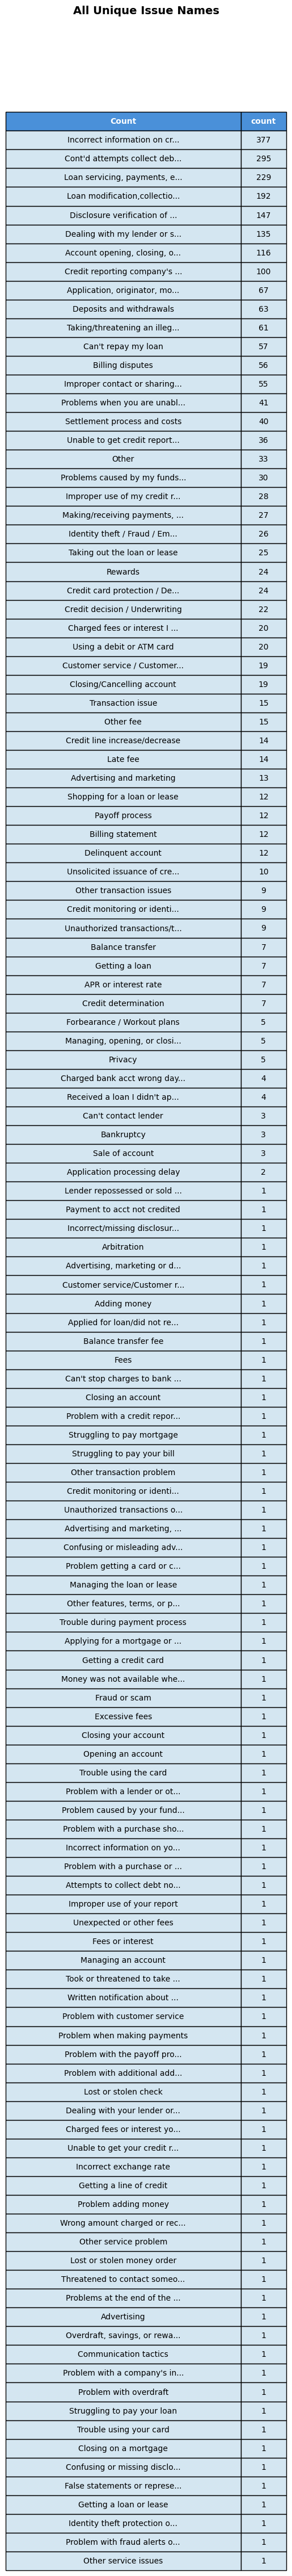

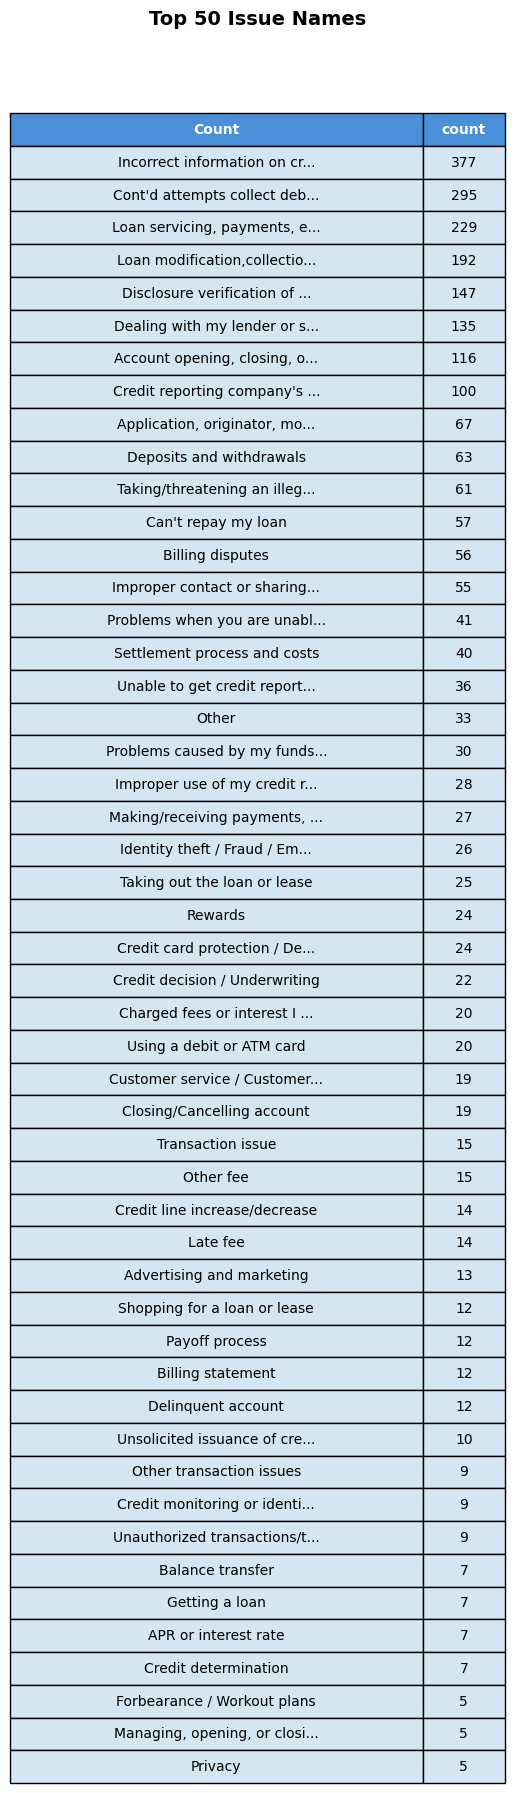

In [79]:
# Issues
issue_names = df_issues['Issue'].unique()

print(f'There {len(issue_names)} Unique Issue Names')
print(issue_names)

df_issue_counts = (df_issues['Issue']
                   .value_counts()
                   .reset_index()
                   .rename(columns={'index': 'Issue', 'Issue': 'Count'}))

df_issue_counts.index += 1  
df_issue_counts.index.name = 'Rank'
DisplayTable(df_issue_counts, 'All Unique Issue Names')
DisplayTable(df_issue_counts.head(50), 'Top 50 Issue Names')

#### Departments - EDA Analysis ####
- Departments -> Department 
    - No missing values
    - No data transformations/conversions required
    - Target categories where complaints will be routed</br>
    Grab the unique values and hold onto them for later use.</br>
    There 7 unique department names.</br>
    There 17 unique product names.</br>

In [80]:
# Departments
department_names = df_departments['Department'].unique()

print(f'There {len(department_names)} Unique Department Names')
print(department_names)

# Products
product_names = df_departments['Product'].unique()
print(f'There {len(product_names)} Product Names')
print(product_names)

There 7 Unique Department Names
['CASA' 'Credit Reports' 'Credit Cards' 'Loans' 'Remittance' 'Mortgage'
 'Others']
There 17 Product Names
['Checking or savings account'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Credit card or prepaid card' 'Debt collection'
 'Money transfer, virtual currency, or money service' 'Mortgage'
 'Vehicle loan or lease' 'Payday loan, title loan, or personal loan'
 'Student loan' 'Credit Card' 'Credit Reporting' 'Payday loan'
 'Bank Account or Service' 'Money transfers' 'Prepaid Card'
 'Consumer Loan' 'Other financial service']


In [81]:
#### Merge Issues into Complaints Data Frame
df_complaints_and_issues = pd.merge(df_complaints, df_issues, left_on='Issue ID', right_on='Issue_ID', how='left')

df_complaints_and_issues.drop(columns=['Complaint ID', 'Issue_ID'], inplace=True)

# PrintDataFrameStatistics('Merged Complaints And Issues', df_complaints_and_issues)
# print()

#### Merge Datasets into 1 DataFrame ####
Merge issues dataset into complaints so issues are included in complaint dataset.</br>
Complaint dataset will contain all relative data. </br>
</br>
Dropping **ComplaintID** and **Issue ID** columns from dataset as they serve no predictive or analytical purpose.</br>
They are unique identifiers "imported" from original system/dataset.

### 3.2 Plotting Data for Additional Insights

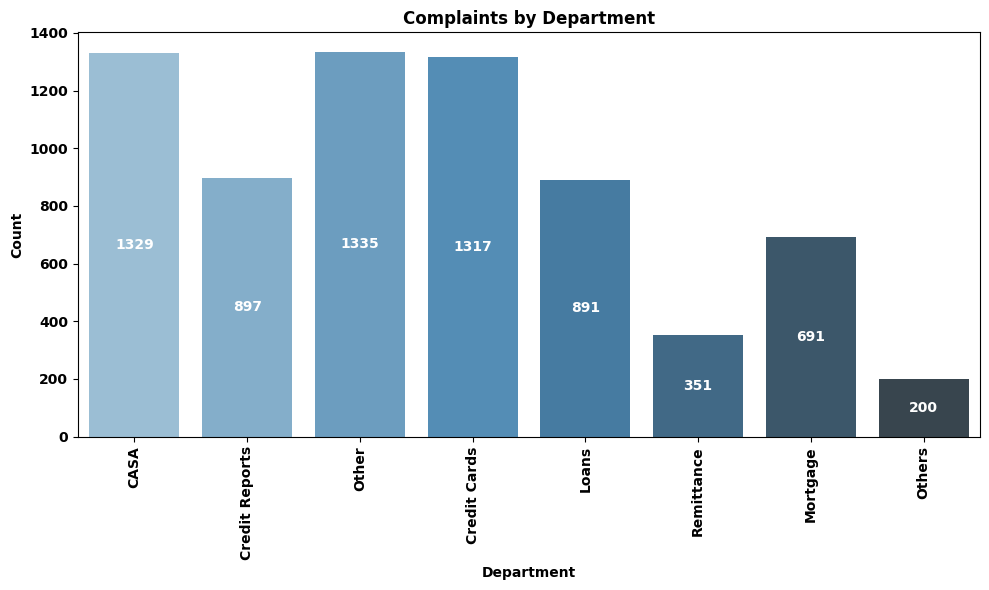

/tmp/ipykernel_15511/161496067.py:70: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


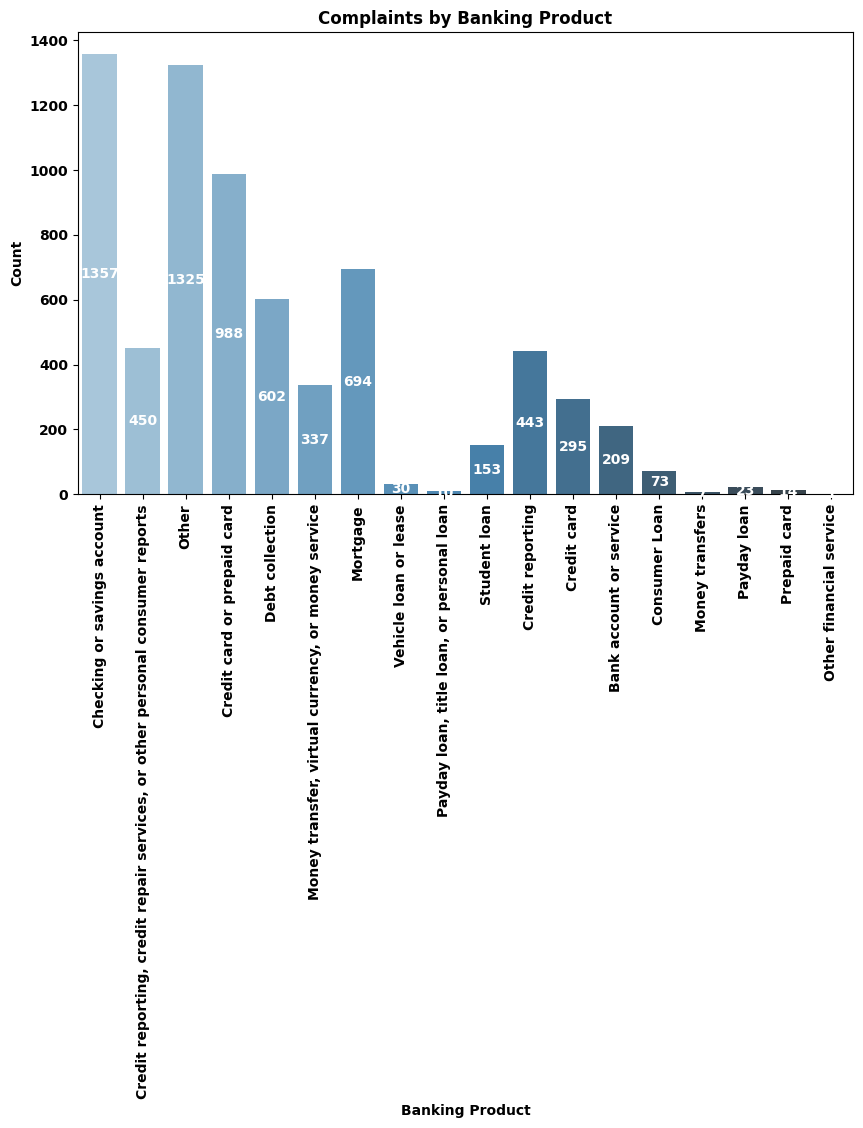

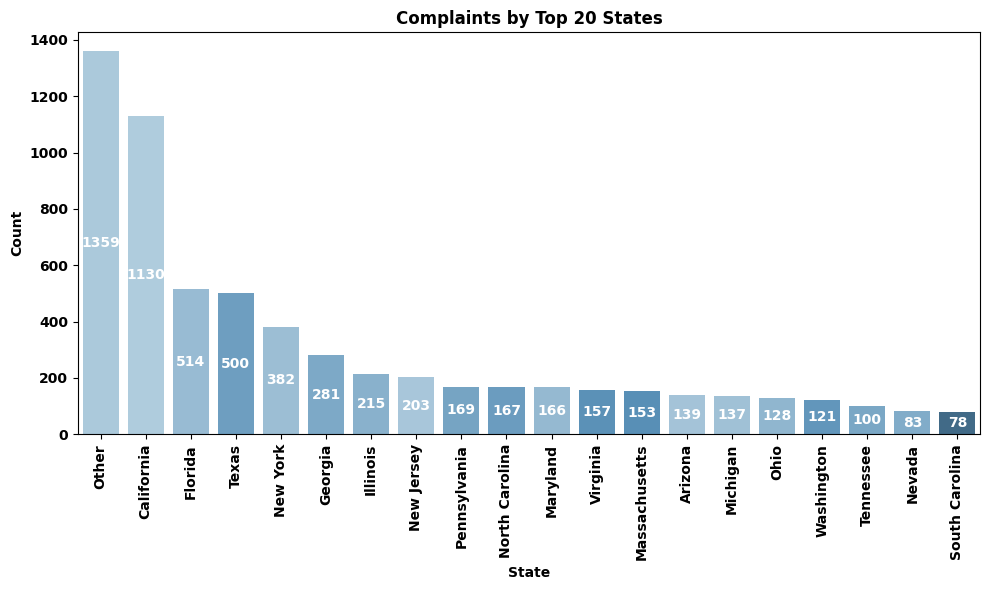

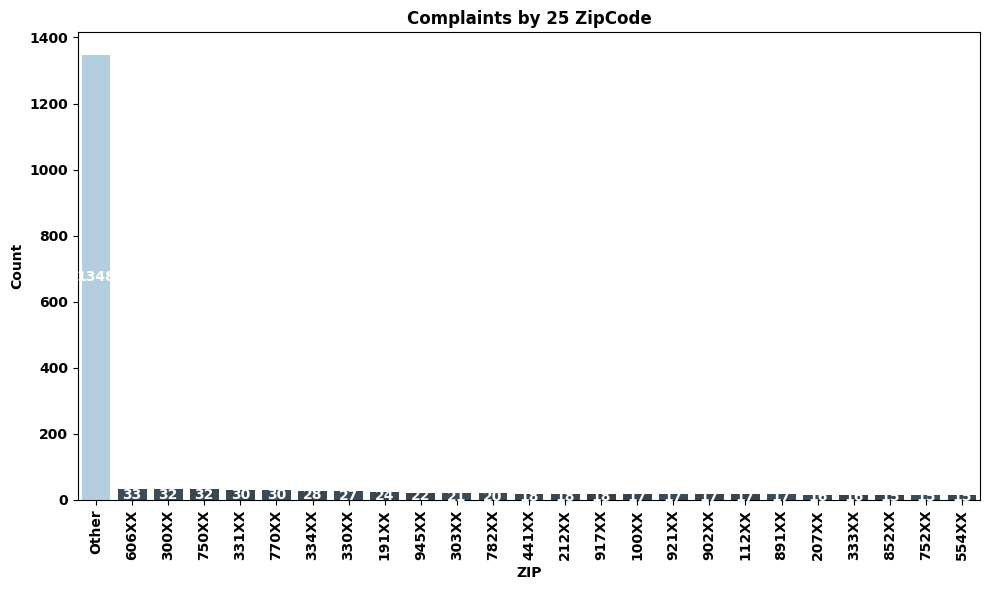

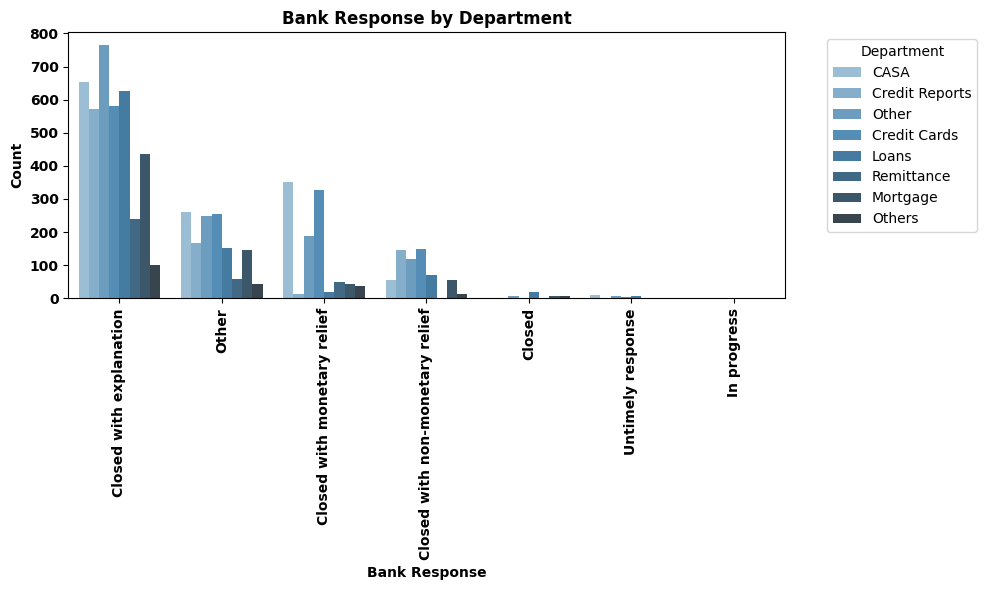

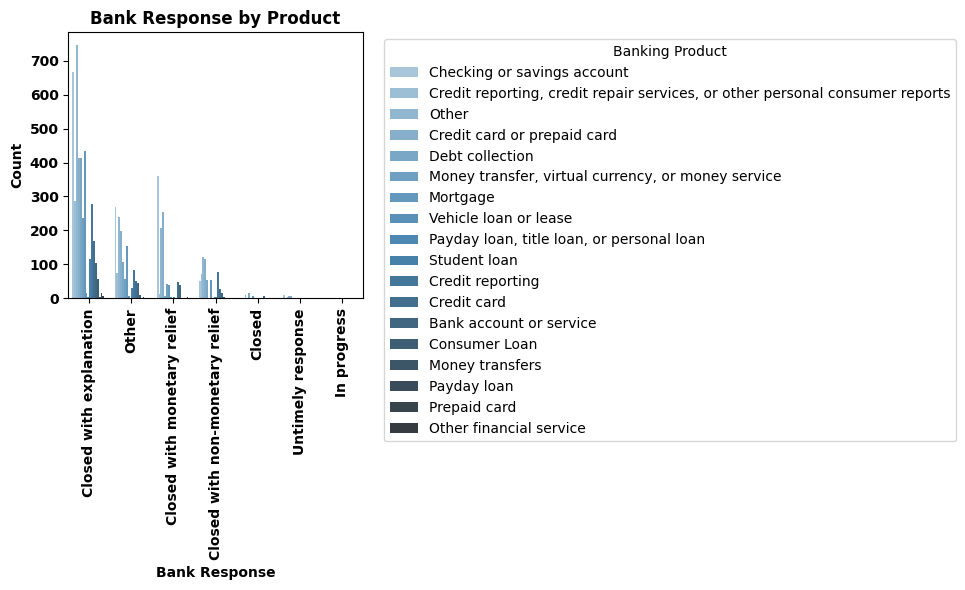

/tmp/ipykernel_15511/161496067.py:93: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


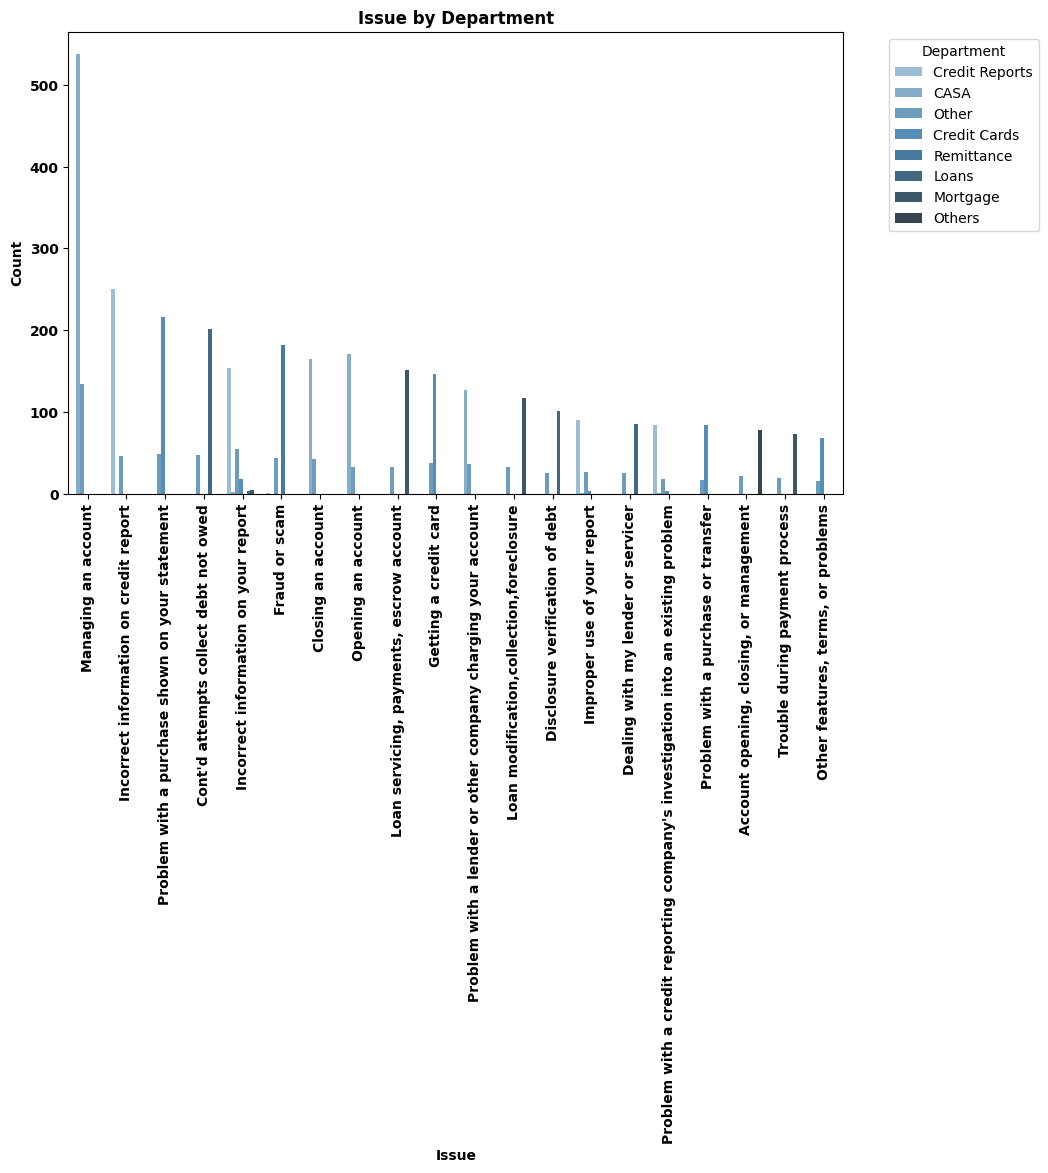

/tmp/ipykernel_15511/161496067.py:93: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


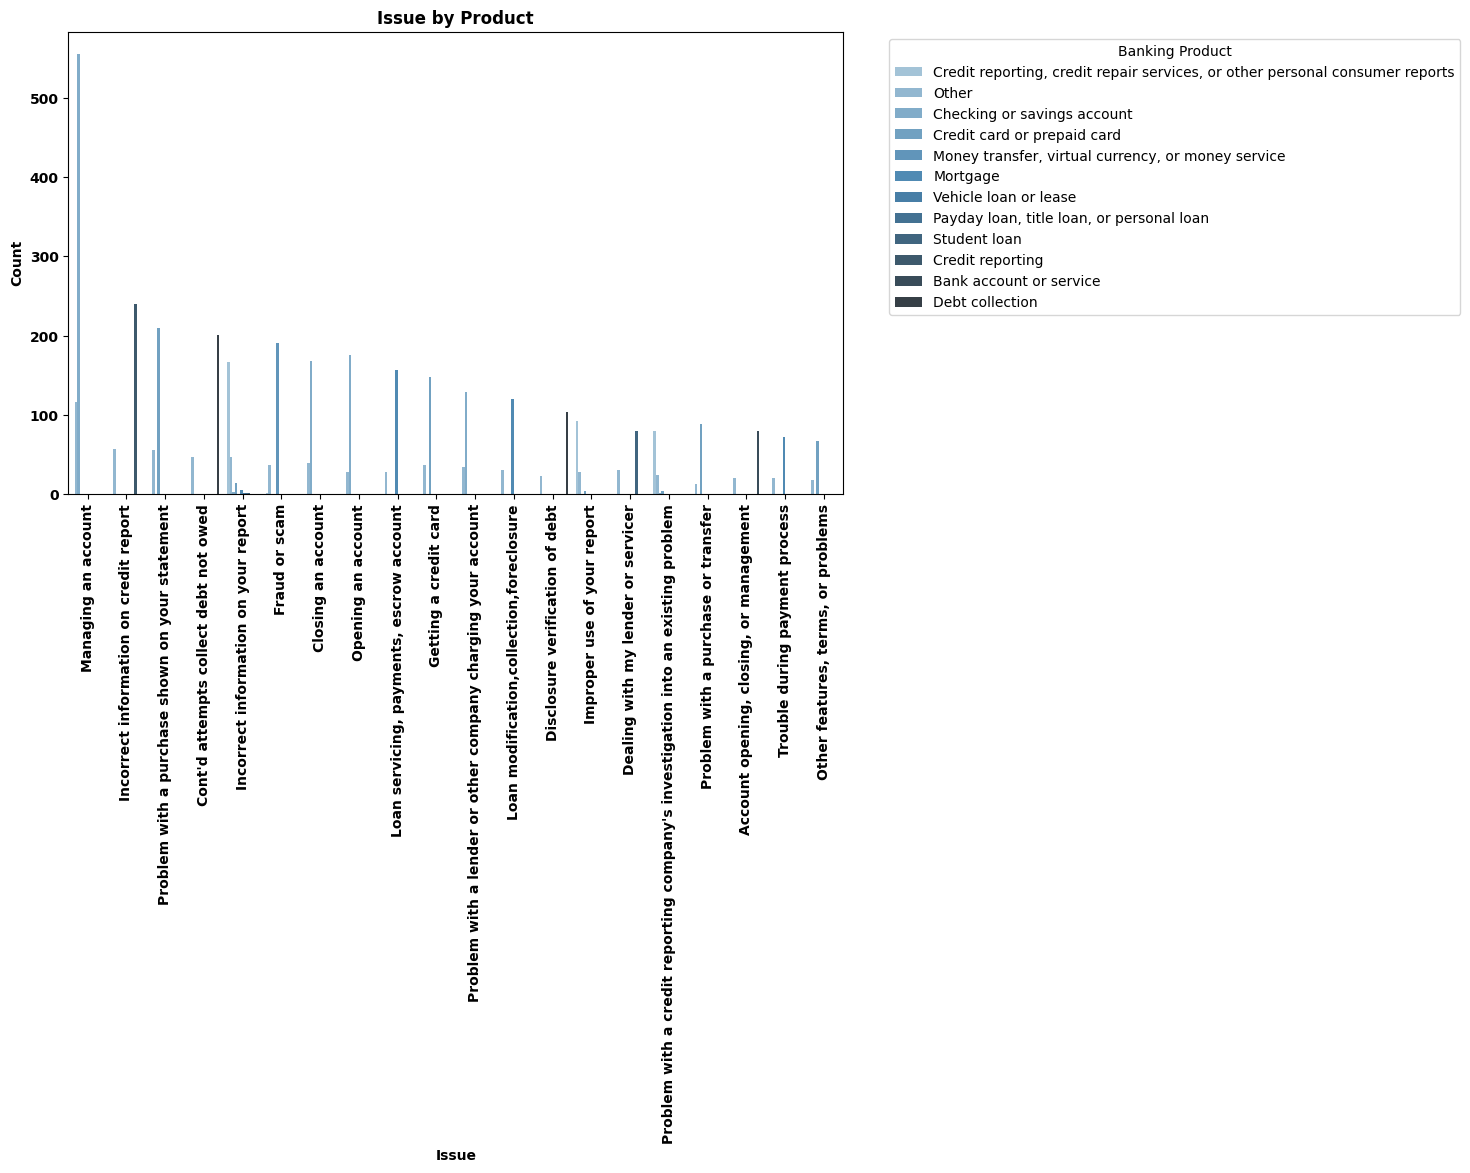

/tmp/ipykernel_15511/161496067.py:93: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


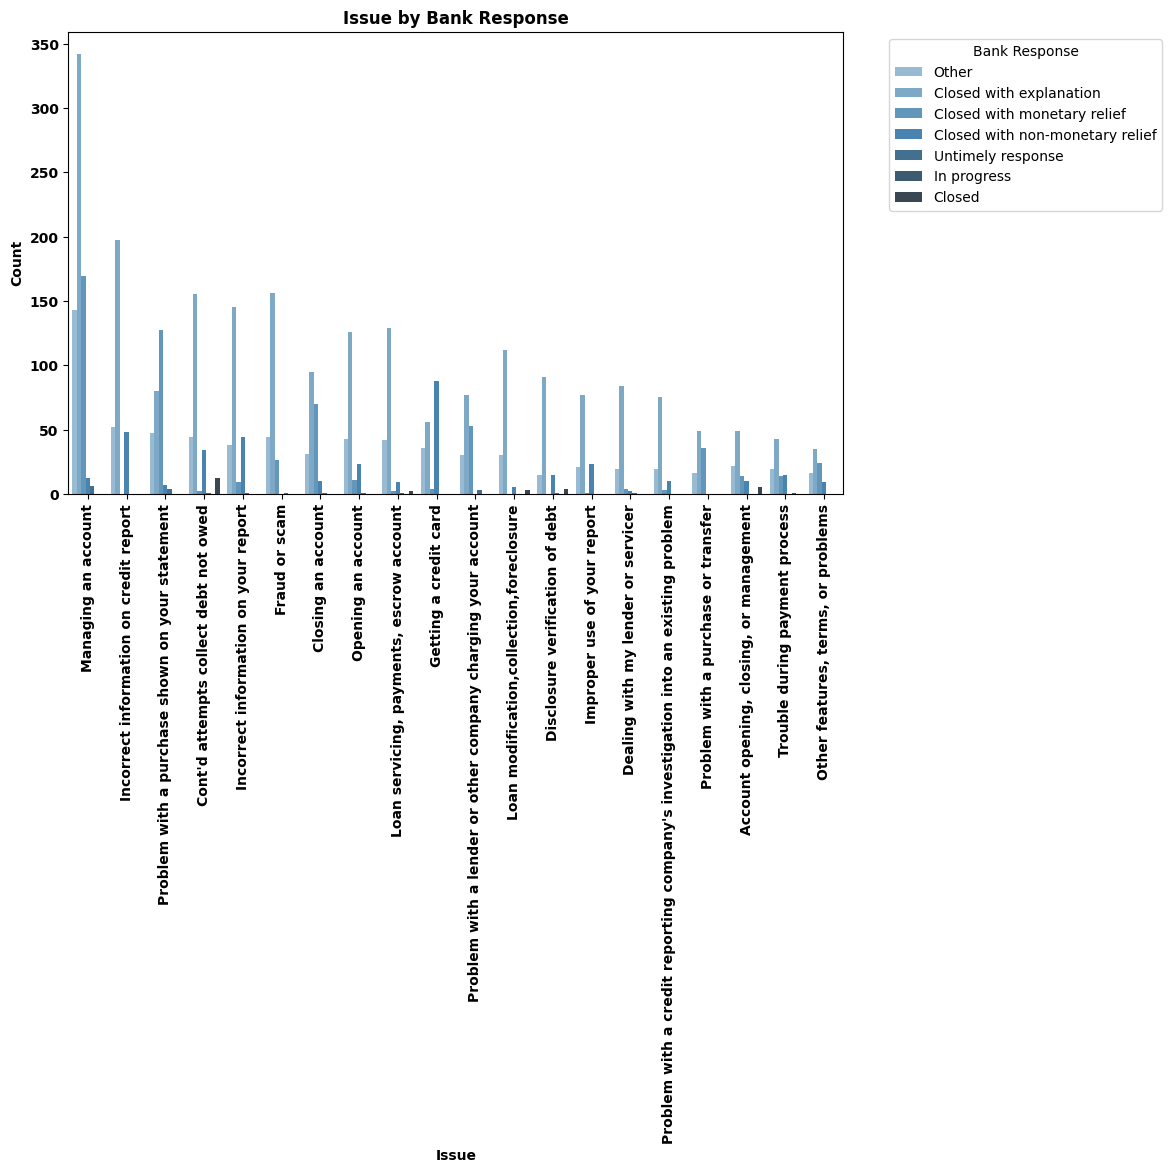

Complaints Date Range: 2023-01-01 00:00:00 to 2023-10-21 00:00:00


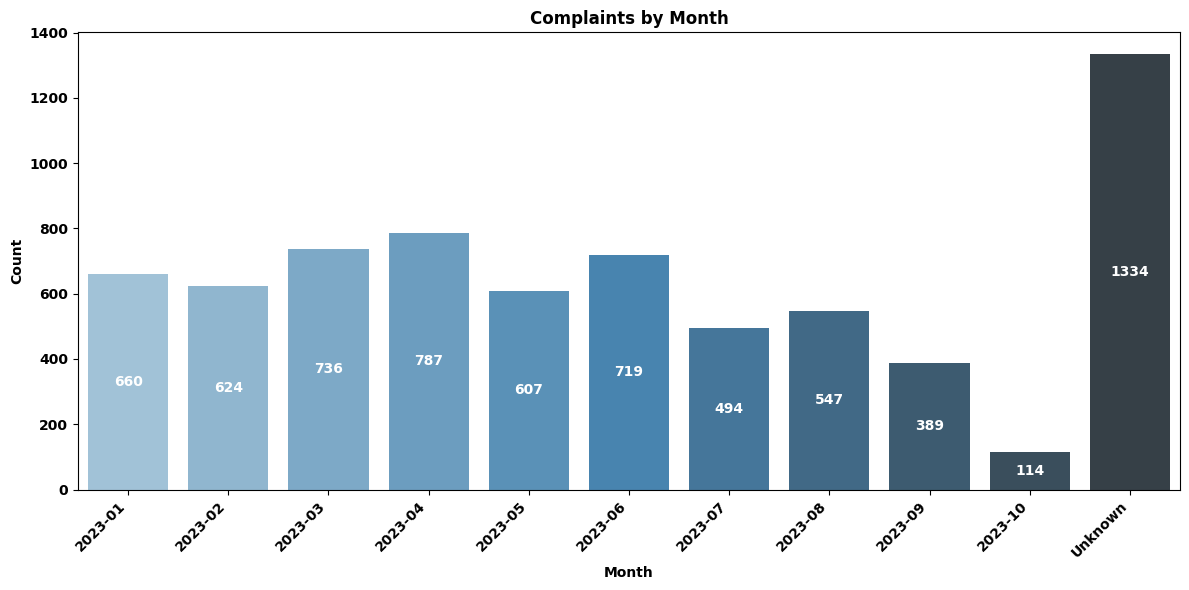

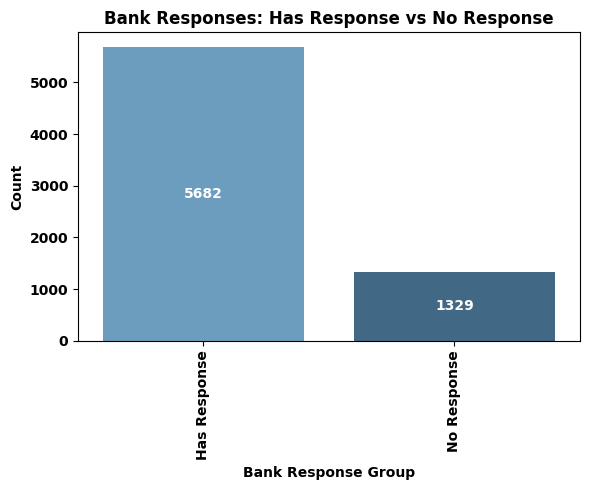

In [82]:
# Department Count Plot
departmentOrder = df_complaints_and_issues['Department'].unique().tolist()
DisplayCountPlot(df_complaints_and_issues, 'Department', departmentOrder, 'Complaints by Department', (10,6))

# Banking Products 
bankingProducts = df_complaints_and_issues['Banking Product'].unique().tolist()
DisplayCountPlot(df_complaints_and_issues, 'Banking Product', bankingProducts, 'Complaints by Banking Product', (10,6))

# State Distribution
states = df_complaints_and_issues['State'].value_counts().head(20).index.tolist()
DisplayCountPlot(df_complaints_and_issues, 'State', states, 'Complaints by Top 20 States', (10,6))

# Zip Codes
zipCodes = df_complaints_and_issues['ZIP'].value_counts().head(25).index.tolist()
DisplayCountPlot(df_complaints_and_issues, 'ZIP', zipCodes, 'Complaints by 25 ZipCode', (10,6))

# "Bank Response" by Department
DisplayGroupedCountPlot(df_complaints_and_issues, 'Bank Response', 'Department',  'Bank Response by Department', (10, 6))

# "Bank Response" by "Banking Product"
DisplayGroupedCountPlot(df_complaints_and_issues, 'Bank Response', 'Banking Product', 'Bank Response by Product', (10, 6))

# Issue by Department
DisplayGroupedCountPlot(df_complaints_and_issues, 'Issue', 'Department',      'Issue by Department', (10, 6), top_n=20)

# Issue by "Banking Product"
DisplayGroupedCountPlot(df_complaints_and_issues, 'Issue', 'Banking Product', 'Issue by Product', (10, 6), top_n=20)

# Issue by "Banking Response"
DisplayGroupedCountPlot(df_complaints_and_issues, 'Issue', 'Bank Response',   'Issue by Bank Response', (10, 6), top_n=20)


# Bin and plot complaints by month
print('=' * 60)
print(f"Complaints Date Range: {df_complaints_and_issues['Date Received'].min()} to {df_complaints_and_issues['Date Received'].max()}")
print('=' * 60)

# Deal with Nat by putting in default date 
df_complaints_and_issues['Date Received'] = df_complaints['Date Received'].fillna(pd.Timestamp('1900-01-01'))

# Create month bin column
df_complaints_and_issues['Month'] = df_complaints_and_issues['Date Received'].dt.to_period('M').astype(str)

# Create a meaningful label before binning
df_complaints_and_issues['Month'] = df_complaints_and_issues['Month'].replace('1900-01', 'Unknown')

# Aggregate counts per month
df_monthly = (df_complaints_and_issues
              .groupby('Month')
              .size()
              .reset_index(name='Count')
              .sort_values('Month'))

# Plot using your existing DisplayBarPlot function
DisplayBarPlot(df_monthly, 
               x_axis='Month', 
               y_axis='Count',
               x_axis_label='Month',
               y_axis_label='Count',
               plot_title='Complaints by Month')


# Plot all Bank Response values, colored by Blank vs Non-Blank status
df_complaints_and_issues['Bank Response Group'] = df_complaints_and_issues['Bank Response'].apply(
                                                                                                    lambda x: 'No Response' if x == 'Other' else 'Has Response'
                                                                                                )

status_order = ['Has Response', 'No Response']

DisplayCountPlot(df_complaints_and_issues,
                 'Bank Response Group',
                 status_order,
                 'Bank Responses: Has Response vs No Response',
                 (6, 5))        


#### EDA Plot Analysis
Analysis of distribution plots

- **Complaints by Department**
    - CASA, Credit Reports and Credit Cards have highest number of complaints
	- "Other" scores high too; customer service reps aren't following work flow/filling things out correctly/consistently
	- Remittance and Mortgage have lowest number of complaints
- **Complaints by Banking Products** 
    - Checking/Savings Account, Credit/prepaid Cards, Mortgage have highest number complaints
	- Other scores high again (see above for more info)
- **Complaints by States**
    - California, Florida, Texas, New York have highest number of complaints
	- Tenn, Nevada and S. Carolina have lowest number
	- Other scores high again (see above for more info)
	Is this evenly distributed based on state populations?
- **Complaints by Zip Codes**
    - Complaints seem to be evenly distributed across zip codes
	- Other scores high again (see above for more info)
- **Bank Response by Department**
    - **Closed** (with relief/explanation) is the highest scoring bank response across all departments
	- Other scores high again (see above for more info)
- **Bank Response by Banking Product**
	- **Closed** (with relief/non-relief/explanation) is the highest scoring bank response across all departments
	- Other scores high again (see above for more info)
- **Issues by Department**
    - Highest issues are:
		- Managing an account
		- Credit report errors
		- Monthly statement inaccuracies
		- Collection attempts
		- REport inaccuracies
		- Fraud/Scam
		- Opening/Closing an account
- **Issues by "Banking Product"**
    - Mirrors Issues by Department (See above)
- **Issues by "Banking Response"**
    - Account Management, Closed with Explanation response id the dominant issues
	- Followed by credit report inaccuracies with Close (non-relief) as response
- **Complaints by Month**
    - Peak months are March, April and June
	- A noticeable decrease (with slight August bump) from July to end of reporting period (October)
	- Other/Unknown scores high again (see above for more info)	
- **Bank Responses - Has Responses/No Responses**
    - Bank customer failed to respond to complaints 19% of the time
    - Is this part of their calculated business model? </br>
    Don't respond to a percentage of complaints hoping they just go away?

## 4.0 Data Wrangling/Preprocessing ##

## **2.0 Text Exploration - The Labeled Review Dataset** ##
## 2.1 Word Frequency Analysis ##
Word frequency analysis across entire corpus.</br>
BeautifulSoup added to preprocess_text() to remove 'HTML' tags from each review</br>
Slows preprocessing down, but more accurate than relying on RegEx()</br>

In [83]:
# Preprocess function for full corpus
def preprocess_text(text):

    # Probably more efficient way to do this, but this isn't a programming class.
    clean_text = BeautifulSoup(text, 'html.parser').get_text()

    tokens = word_tokenize(clean_text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

# Get all tokens from corpus
all_tokens = []

for text in df_labeledMovieReviews['review']:
    all_tokens.extend(preprocess_text(text))

# Count word frequencies
word_freq = Counter(all_tokens)
top_20 = word_freq.most_common(20)

# The number of unique words in the Dataset
print("Number of unique words across all the reviews")
print(f"Unique Words: {len(word_freq)}")

# Display top words
freq_df = pd.DataFrame(top_20, columns=['word', 'count'])
print("Top 20 most frequent words")
freq_df

NameError: name 'df_labeledMovieReviews' is not defined

#### Word Frequency Analysis and Observations
Initially, I noticed there is a high frequency of the token "**br**"</br>
Upon further examination of the original data set this because html linebreaks are embedded in the reviews.</br>
This was be cleaned up as it could/will skew any training/predictions we do.</br>
</br>

#### Identify the Unknown Words
I would like to examine the entire corpus and identify any unknown/unrecognized words and their frequency. </br>
Some of these words might be slangs, some might be legitimate misspellings. </br>
With 70K-ish tokens this shouldn't be a heavy lift.</br>
Once examining the results, I can make a strategy (if any) to deal with unknown/misspelled words.</br>
We're not going to worry about punctuation correctness as punctuation will get filtered out through pre-processing. </br>
</br>
Surprisingly, there are over 26K unknown words in the tokens.</br>
Before deciding whether or not I'm just chasing down a potential rabbit hole, examine the following:</br>
- Most common unknown words
- Middle common unknown words
- Least common unknown words


In [ ]:
spell_checker = SpellChecker()

all_unique_words = list(word_freq.keys())
unknown_words = spell_checker.unknown(all_unique_words)
print(f"Number of Unique Unknown Words: {len(unknown_words)}")

# Get frequency of unknown word instances
unknown_freqs = [(word, word_freq[word]) for word in unknown_words]
unknown_freqs.sort(key=lambda x: x[1], reverse=True)

# Words occurring over 100 times
most_common_unknown_words = [item for item in unknown_freqs if item[1] > 100]
print(f"20 most common unknown words (Total {len(most_common_unknown_words)}) ---")
print(most_common_unknown_words[:20])

# Words occurring between 5 and 10 times
middle_used_unknown_words = [item for item in unknown_freqs if 5 <= item[1] <= 10]
print(f"20 most common averagely used unknown words (Total {len(middle_used_unknown_words)}) ---")
print(middle_used_unknown_words[:20])

# Words appearing only once
least_common_unknown_words = [item for item in unknown_freqs if item[1] == 1]
print(f"20 least common unknown words (Total {len(least_common_unknown_words)}) ---")
print(least_common_unknown_words[:20])


#### Unique Word Discovery Analysis
I took a quick look at a sampling of the most, average, least number of unknown words.</br>
Based on the output, it looks like all of these are legitimate words coming under the following types:
- slangs
- acronyms 
- abbreviations
- proper names</br>

</br>
Based on that, we can keep the unknown words as part of the overall tokenized corpus as they do carry weight/meaning in the review.


#### Examination of Review Lengths

In [ ]:
# Average character length of a review
average_review_length = df_labeledMovieReviews['review'].str.len().mean()

# Calculate average number of words per review
average_review_word_count = df_labeledMovieReviews['review'].str.split().str.len().mean()

print('============================================================================')
print('Review Length Analysis Results')
print()
print(f'Average Review Length: {average_review_length:.2f}')
print(f'Average Word Count per Review: {average_review_word_count:.2f}')
print()
print('============================================================================')


df_reviewLength = df_labeledMovieReviews.copy(deep=True)
df_reviewLength['average_review_length'] = average_review_length
df_reviewLength['average_review_word_count'] = average_review_word_count

df_labeledMovieReviews.groupby('sentiment')['review'].apply(
                                                                lambda x: x.str.len().mean()
                                                            ).plot(kind='bar')
plt.title('Average Review Length by Rating')
plt.ylabel('Average Review Length')
plt.xlabel('Rating')
plt.show()

df_labeledMovieReviews.groupby('sentiment')['review'].apply(
                                                                lambda x: x.str.split().str.len().mean()
                                                            ).plot(kind='bar')
plt.title('Average Review Word Count by Rating')
plt.ylabel('Average Word Count')
plt.xlabel('Rating')
plt.show()

#### Observations of Review Lengths
Reviews for Negative and Positive sentiments have almost identical average review lengths and word counts.</br>
I'm not sure if that reflects reality or is just a characteristic of this dataset.</br>
I guess that tells the sentiment is not necessarily an indicator of the length of the reviews. </br>
Conversely, a short or long review does not necessarily predict the overall sentiment of the review.</br>

### 2.2 Word Cloud Visualization

In [ ]:
# Create word cloud
wordcloud = WordCloud(
                        width=800,
                        height=400,
                        background_color='white',
                        colormap='Greys'
                    ).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.title('Word cloud of movie reviews corpus')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 2.3 Word Frequency Distribution

In [ ]:
# Histogram of word frequency distribution
word_counts = list(word_freq.values())

plt.figure(figsize=(10, 5))
plt.title('Distribution of word frequencies')
plt.hist(word_counts, bins=100, color='grey', edgecolor='black')
plt.xlabel('Word frequency')
plt.ylabel('Number of words')
plt.yscale('log')  # Use logarithmic scale for better visibility
plt.tight_layout()
plt.show()

#### Word Frequency Observations

## **3.0 Sentiment Analysis** ##
Build sentiment classification models (positive:1 vs negative:0) using the following models:
- Naive Bayes
- Custom LSTM Deep Learning Model
- Pre-trained BERT model from HuggingFace

### 3.1 Naive Bayes Model
This was taken directly from George's Lesson_38_demo notebook.
#### Prepare the data

In [ ]:
# Prepare data
X = df_labeledMovieReviews['review']
y = df_labeledMovieReviews['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
                                                        X, y,
                                                        test_size=0.2,
                                                        random_state=315
                                                    )

# Vectorize text using bag-of-words
vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f'Training set: {X_train_vec.shape}')
print(f'Test set: {X_test_vec.shape}')

#### Train the Model

In [ ]:
# Train Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vec, y_train)

# Predict and evaluate
y_pred = nb_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.3f}\n')
print('Classification report:')
print(classification_report(y_test, y_pred))

### 3.2 VADER Sentiment Analyzer
In keep with the tme from Lesson_38_demo, I thought it would be interesting to explore Rules Based Sentiment Analysis thru VADER.</br>
Once again this was pretty much taken verbatim from George's Lesson_38_demo notebook.

****VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based sentiment analyzer that uses a dictionary of words with pre-assigned sentiment scores.</br>
NLTK [VADER](https://www.nltk.org/howto/sentiment.html) documentation </br>

#### Sentiment Analysis for random sample from that the dataset.

In [ ]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Take 25 random samples from the train split and run thru VADER 
# just to see how they get ranked (satisfy curiosity)

# Analyze sentiment
print('Movie Review Random Sample VADER sentiment scores:\n')

for index, row in df_labeledMovieReviews.sample(25).iterrows():
    scores = sia.polarity_scores(row['review'])
    print(f'Text: {textwrap.fill(row["review"], width=120)}')
    print()
    print(f'Sentiment: {row["sentiment"]}')
    print(f'Sample #{index+1} Scores: {scores}\n')
    print()

#### Apply Vader to test set and compare with feature label

In [ ]:
# Apply VADER to test set
def vader_predict(text):

    scores = sia.polarity_scores(text)
    if scores['compound'] >= 0.05:
        return 1
    elif scores['compound'] <= -0.05:
        return 0
    else:
        return 0  # Default to negative for neutral

# Predict with VADER
y_pred_vader = [vader_predict(text) for text in X_train]
vader_accuracy = accuracy_score(y_train, y_pred_vader)

print(f'VADER accuracy: {vader_accuracy:.3f}')
print(f'Naive Bayes accuracy: {accuracy:.3f}')


#### VADER Analysis
Naive Bayes scored much higher than VADER in terms of Test dataset accuracy.</br>
This expected because **Naives Bayes** is supervised learning while **VADER** is rule based using a dictionary of predefined words and intensity scores. </br>
**Naive Bayes** is a trained model that actually learns, while **VADER** does not.
</br>

### 3.3 Custom Deep Learning model including LSTM layers
Looking at reviews, I thought I'd experiment and play with Sequential Models with a varied number of layers.</br>
Some initial research warned against potential overfitting if applying multi-LSTM layered models against smaller datasets </br>
Giving it some thought.., our dataset isn't necessarily small (maybe in the entire scope of all movie reviews it is...) </br>
The other risk is that I'm only running on a CPU, so it could be pretty slow to process. </br>
Regardless, let's try it out and see what kind fo results we see.

#### Deep Learning (LSTM) Model Creation Functions
I'm going to create 3 distinct DL CNN-LSTM hybridmodels:
- 1 LSTM Layer
- Stacked Models - learn more hierarchical features
    - 2 LSTM Layers  - phrases??
    - 3 LSTM Layers  - sentences ??

Upon building/training and testing the model, I will compare the results to determine the best performing DL model.</br>
I'll use this "**Best of Class**" model in my comparisons with Naive Bayes and the pretrained "Bert" model.


#### Parameter Definitions ####
- **vocab_size** = 25,000
    - Reduce tails/outliers
    - Reduce sparseness of data (sparse matrix)
    - Reduce number of parameters (25K X 300) instead of (75K X 300)
    - Picking 25k most frequent words helps be more compatible with Word2Vec
- **output_dim** = 300
    - Standard vector size originally used on pre-trained Word2Vec
    - Allows for Apples-Apples comparison between **Learned Embedding** and **Word2Vec** models
- **input_length** (review length) = 500 (words)
    - Roughly 2X the average review length (240-ish words)
    - Given average length, ths will capture most of the reviews entirely
    - First 500 words should be enough to get a feeling for the overall climate of a review
    - Have to pad short reviews though

In [ ]:
vocab_size = 25000
output_dim = 300
input_length = 500

#### Model Definitions
Create 4 LSTM-CNN hybrid models.
1. Single LSTM Layer - Embedding (dynamically learns while training)
2. 1 LSTM Layer - Word2Vec (static/pretrained)
3. 2 LSTM Layers (Stacked Model) - Word2Vec
4. 3 LSTM Layers (Stacked Model) - Word2Vec </br>


In [ ]:
# Definition borrowed from previous capstone.
#
def CreateSingleLayerLTSMModel_Embedding(dropout_rate):
    model = Sequential([

        # Embedding - convert 2D sequences into 3D vectors [required by SimpleRNN(), LTSM()]
        # Words -> Numeric Vectors
        Embedding(vocab_size + 1, output_dim, input_length=input_length),
        
        # Block 1: Convolutional
        # Text is 1 dimensional sequence - so use 1D function layers
        # filters => 32, 64, 128 - powers of 2; 
        # relu activation - Standard (default) starting point for activation function selection
        # Find local patterns/phrases
        Conv1D(filters=64, kernel_size=3, activation='relu'),

        # Normalizes activations
        BatchNormalization(),

        # Reduces Dimensions
        MaxPooling1D(pool_size=2),

        # Randomly drop/turn-off neurons
        Dropout(dropout_rate),
        
        # Block 2: Recurrent
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),
        
        # Block 3: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        # Binary classification: squashes sentiment between 0 or 1
        Dense(1, activation='sigmoid')  
    ])

    return model

# 1 LSTM Layer
def CreateLSTMModel_Word2Vec(dropout_rate, embedding_matrix):
    model = Sequential([

        # Embedding: initialized with Word2Vec weights, frozen (not trainable)
        Embedding(input_dim=vocab_size + 1, 
                  output_dim=output_dim, 
                  input_length=input_length,
                  weights=[embedding_matrix],
                  trainable=False),  # Set True to fine-tune

        # Block 1: Convolutional
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Block 2: Recurrent
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),

        # Block 3: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    return model


def CreateLSTMModel_Word2Vec_2LSTM(dropout_rate, embedding_matrix):
    model = Sequential([

        # Embedding: initialized with Word2Vec weights, frozen (not trainable)
        Embedding(input_dim=vocab_size + 1, 
                  output_dim=output_dim, 
                  input_length=input_length,
                  weights=[embedding_matrix],
                  trainable=False),

        # Block 1: Convolutional
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Block 2: Recurrent - LSTM 1
        # return_sequences=True required to pass sequence to next LSTM layer
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),

        # Block 3: Recurrent - LSTM 2
        # return_sequences=False - last LSTM collapses sequence to single vector
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),

        # Block 4: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    return model

def CreateLSTMModel_Word2Vec_3LSTM(dropout_rate, embedding_matrix):
    model = Sequential([

        # Embedding: initialized with Word2Vec weights, frozen (not trainable)
        Embedding(input_dim=vocab_size + 1, 
                  output_dim=output_dim, 
                  input_length=input_length,
                  weights=[embedding_matrix],
                  trainable=False),

        # Block 1: Convolutional
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Block 2: Recurrent - LSTM 1
        LSTM(128, return_sequences=True),
        Dropout(dropout_rate),

        # Block 3: Recurrent - LSTM 2
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),

        # Block 4: Recurrent - LSTM 3
        # Last LSTM collapses sequence to single vector
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),

        # Block 5: Dense
        Dense(32, activation='relu'),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])

    return model



#### Preprocess Text Review Data
Apply texting preprocessing and lemmatization before building/processing DL models.
Choosing lemmatization over stemming because I prefer more accurate - dictionary-ish approach.

In [ ]:
lemmatizer = WordNetLemmatizer() 

# Preprocess function for full corpus
def preprocess_text_for_lstm(text):
    clean_text = BeautifulSoup(text, 'html.parser').get_text()
    tokens = word_tokenize(clean_text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    
    # Lemmatize each token
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return tokens

#### Final Text Preprocessing and Test/Train Split #####
Now we are at the point of preparing the data for actual model training.</br>
The final preparation included the following steps:
1. Text Preprocessing
    - Preprocess (text) the entire corpus before completing the required splits.
2. Train/Test Splits
    - i) Initial 80/20 Train/Test split of entire dataset
    - ii) Split Train dataset 80/20 into Train/Validation datasets
3. Tokenization
    - Tokenize the split datasets into tokens for consumption by models
4. Pad Sequences
    - Pad the tokenized datasets to max length so they are all equal length (better for model performance)

</br>
**Note:** I was trying to be cognizant of potential data leakage during these steps

In [ ]:
# Preprocess ENTIRE Dataset 
debug_datasample_size = None
df_labeledMovieReviews['tokens'] = df_labeledMovieReviews['review'].apply(
    lambda x: ' '.join(preprocess_text_for_lstm(x))
)


#################################################################################################
# # For testing/debugging purposes, take just 100 rows
# debug_datasample_size = 5
# df_labeledMovieReviews['tokens'] = df_labeledMovieReviews['review'].head(5).apply(
#     lambda x: ' '.join(preprocess_text_for_lstm(x))
# )
# # Drop rows where tokens were not assigned (rows 101-25000)
# df_labeledMovieReviews = df_labeledMovieReviews.dropna(subset=['tokens'])  
#################################################################################################

# for text in df_labeledMovieReviews['review']:
#     all_tokens.extend(preprocess_text_for_lstm(text))

# Extract X and y
X_raw = df_labeledMovieReviews['tokens'].values
y     = df_labeledMovieReviews['sentiment'].values

# Initial Train/Test split into 80/20 split
X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
                                                                    X_raw, 
                                                                    y, 
                                                                    test_size=0.2, 
                                                                    random_state=42
                                                                )

# Split Validation from Train - 80/20 split Train/Validation
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
                                                            X_trainval_raw, 
                                                            y_trainval, 
                                                            test_size=0.2,
                                                            random_state=42
                                                        )

print(f'X_train shape: {len(X_train_raw)}')
print(f'X_val   shape: {len(X_val_raw)}')
print(f'X_test  shape: {len(X_test_raw)}')

# Fit Tokenizer on Train Only (prevents data leakage) ──────────────
tokenizer_tool = Tokenizer(num_words=vocab_size)
tokenizer_tool.fit_on_texts(X_train_raw)

# Tokenize and Pad All 3 Splits - Train, Validation, Test
X_train = pad_sequences(tokenizer_tool.texts_to_sequences(X_train_raw), maxlen=input_length, padding='post')
X_val   = pad_sequences(tokenizer_tool.texts_to_sequences(X_val_raw),   maxlen=input_length, padding='post')
X_test  = pad_sequences(tokenizer_tool.texts_to_sequences(X_test_raw),  maxlen=input_length, padding='post')

#### Hyperparameter Definitions

In [ ]:
dropout_rates  = [0.2, 0.3, 0.4, 0.5]
learning_rates = [0.001, 0.0001]
batch_sizes    = [32, 64, 128]
thresholds     = [0.3, 0.4, 0.5, 0.6, 0.7]

#### Create Word2Vec Embedding Matrix
Based on Lesson_39_demo

In [ ]:
# Create Word2Vec Model
# Parameters based on Lesson_39_demo
w2v_model = Word2Vec(
                        sentences=all_tokens,        # List of tokenized documents
                        vector_size=output_dim,      # Dimensionality of the embedding
                        window=5,                    # Context window size (words before/after target)
                        min_count=5,                 # Minimum word frequency to include in vocabulary
                        seed=315                     # Random seed for reproducibility
                    )

print(f'Vocabulary size: {len(w2v_model.wv)}')

def CreateEmbeddingMatrix(word_index, w2v_model, embedding_dim=300):

    embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
    
    for word, idx in word_index.items():
        if idx <= vocab_size and word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
    return embedding_matrix

word_index = tokenizer_tool.word_index

embedding_matrix = CreateEmbeddingMatrix(
                                            word_index    = word_index,
                                            w2v_model     = w2v_model,
                                            embedding_dim = output_dim      
                                        )

print(f'Embedding matrix shape: {embedding_matrix.shape}')

#### Model Hyperparameter Tuning and Evaluation
Iterate through the hyperparameters to find the best combination for each of the model flavours.</br>
Use validation split to track model performance on "unseen data" during training.</br>
Track and keep a running accumlulator of the results.</br>
Based on f1_scores determine the best weights.</br></br>
Utilize 2 callbacks:
- EarlyStopping
    - Monitor validation loss and stop when model no longer learns/improves
- Checkpoint
    - Save best training weights in event of failure/system crash

In [ ]:
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.metrics import Precision, Recall, AUC
# from sklearn.metrics import (
#     confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay,
#     classification_report, precision_score, recall_score, f1_score, roc_auc_score
# )
# debug_datasample_size = 5

def TuneAndEvaluateModel(model_name, create_model_fn, model_fn_args,
                          X_train, y_train, X_val, y_val, X_test, y_test,
                          dropout_rates, learning_rates, batch_sizes, thresholds,
                          epochs=10):

    print('=================================================================================================')
    print(f'Evaluating Model: {model_name}')

    total_combinations = len(dropout_rates) * len(learning_rates) * len(batch_sizes) * len(thresholds)
    print(f'Total hyperparameter combinations: {total_combinations}')

    # Callbacks
    checkpoint_path = f'models/checkpoint_{model_name}.weights.h5'

    # Using patience of 7 as a 'happy medium' - not too conservative or aggressive
    early_stopping = EarlyStopping(
                                    monitor='val_loss',
                                    patience=7,
                                    restore_best_weights=True
                                )

    # Trying to use rolling checkpoint as precaution/fallback protection against model crashes
    checkpoint = ModelCheckpoint(
                                    filepath=checkpoint_path,
                                    monitor='val_loss',
                                    save_best_only=True,
                                    save_weights_only=True,
                                    verbose=1
                                )

    tuning_results = []
    combo_num      = 0
    best_val_f1    = -1         # -1 guarantees first combo always sets best_result
    best_result    = None
    best_weights   = None
    best_history   = None       

    for dropout_rate, learning_rate, batch_size in product(dropout_rates, learning_rates, batch_sizes):

        # Build the model
        model = create_model_fn(dropout_rate, **model_fn_args)

        # Compile the model with varied learning_rate
        # Adam optimizer adjusts learning rates for each parameter
        # (More efficient)
        model.compile(
                        optimizer=Adam(learning_rate=learning_rate),
                        loss='binary_crossentropy',
                        metrics=[
                                    'accuracy',
                                    Precision(name='precision'),
                                    Recall(name='recall'),
                                    AUC(name='auc')
                                ]
                    )

        #model.summary()

        history = model.fit(
                            X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping, checkpoint],
                            verbose=1
                        )

        # Final epoch loss values from history
        final_loss     = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]

        # Get raw probabilities once — reuse for all thresholds
        val_probs = model.predict(X_val)

        for threshold in thresholds:

            combo_num += 1
            print(f'Combo {combo_num} dropout={dropout_rate} learning_rate={learning_rate} batch={batch_size} threshold={threshold}')

            y_pred_val = (val_probs > threshold).astype(int)
            val_f1     = f1_score(y_val, y_pred_val, zero_division=0)

            # Accumulate a running collection of results
            # zero_division=0 gets rid of undefined metric warning
            tuning_results.append({
                                    'model_name':    model_name,
                                    'run':           combo_num,
                                    'dropout_rate':  dropout_rate,
                                    'learning_rate': learning_rate,
                                    'batch_size':    batch_size,
                                    'threshold':     threshold,
                                    'loss':          final_loss,
                                    'val_loss':      final_val_loss,
                                    'val_accuracy':  accuracy_score(y_val,  y_pred_val),
                                    'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
                                    'val_recall':    recall_score(y_val,    y_pred_val, zero_division=0),
                                    'val_f1':        val_f1,
                                })

            # If f1_score improves, we've got a new best model
            if val_f1 > best_val_f1:

                best_val_f1  = val_f1
                best_weights = model.get_weights()
                best_history = history.history  
                best_result  = {
                                'model_name':    model_name,
                                'best_run':      combo_num,
                                'dropout_rate':  dropout_rate,
                                'learning_rate': learning_rate,
                                'batch_size':    batch_size,
                                'threshold':     threshold,
                                'loss':          final_loss,
                                'val_loss':      final_val_loss,
                                'val_accuracy':  accuracy_score(y_val,  y_pred_val),
                                'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
                                'val_recall':    recall_score(y_val,    y_pred_val, zero_division=0),
                                'val_f1':        val_f1,
                            }
                print(f'  *** New best — Run {combo_num} — '
                      f'F1: {val_f1:.4f}  threshold: {threshold} ***')

    # Best Hyperparameters Summary
    df_tuning = pd.DataFrame(tuning_results)
    print(f'======================================================================')
    print(f'{model_name} Tuning Results')
    print(f'======================================================================')
    print(df_tuning.sort_values('val_f1', ascending=False).to_string())

    print(f'======================================================================')
    print(f'{model_name} Best Hyperparameters')
    print(f'======================================================================')
    print(f'Best Run      : {best_result["best_run"]} of {total_combinations}')
    print(f'dropout_rate  : {best_result["dropout_rate"]}')
    print(f'learning_rate : {best_result["learning_rate"]}')
    print(f'batch_size    : {best_result["batch_size"]}')
    print(f'threshold     : {best_result["threshold"]}')
    print(f'Loss          : {best_result["loss"]:.4f}')
    print(f'Val Loss      : {best_result["val_loss"]:.4f}')
    print(f'Validation F1 : {best_result["val_f1"]:.4f}')
    print(f'Checkpoint    : {checkpoint_path}')
    print()

    # Restore Model with Best Weights
    best_model = create_model_fn(best_result['dropout_rate'], **model_fn_args)
    best_model.compile(
                        optimizer=Adam(learning_rate=best_result['learning_rate']),
                        loss='binary_crossentropy',
                        metrics=[
                                    'accuracy',
                                    Precision(name='precision'),
                                    Recall(name='recall'),
                                    AUC(name='auc')
                                ]
                    )

    # Build the model by passing one sample through before setting weights
    best_model.predict(X_train[:1], verbose=0)
    best_model.set_weights(best_weights)

    # Use Best Model against the Test Split
    test_probs  = best_model.predict(X_test)
    y_pred_test = (test_probs > best_result['threshold']).astype(int)

    # Save best model weights to disk
    best_weights_path = f'models/best_{model_name}.weights.h5'
    best_model.save_weights(best_weights_path)
    print(f'Best weights saved: {best_weights_path}')

    print(f'======================================================================')
    print(f'{model_name} Final Test Set Results')
    print(f'======================================================================')
    best_model.summary()
    print()
    print(f'Best Run  : {best_result["best_run"]} of {total_combinations}')
    print(f'Threshold : {best_result["threshold"]}')
    print(f'Accuracy  : {accuracy_score(y_test,  y_pred_test):.4f}')
    print(f'Precision : {precision_score(y_test, y_pred_test):.4f}')
    print(f'Recall    : {recall_score(y_test,    y_pred_test):.4f}')
    print(f'F1        : {f1_score(y_test,        y_pred_test):.4f}')
    print()

    # This fails when sample size too small
    if debug_datasample_size is None:
        print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))
        print('Confusion Matrix:')
        print(confusion_matrix(y_test, y_pred_test))

    print(f'======================================================================')
    print(f'======================================================================')
    print()
    print()

    return best_result, best_weights, best_model, best_history, df_tuning  

#### 3.3.1 Single LSTM Layer with Embedding

In [ ]:
best_result_emb, best_weights_emb, best_model_emb, best_history_emb, df_tuning_emb = TuneAndEvaluateModel(
                                                                                                            model_name      = 'Embedding-1LSTM',
                                                                                                            create_model_fn = CreateSingleLayerLTSMModel_Embedding,
                                                                                                            model_fn_args   = {},
                                                                                                            X_train=X_train, 
                                                                                                            y_train=y_train,
                                                                                                            X_val=X_val,     
                                                                                                            y_val=y_val,
                                                                                                            X_test=X_test,   
                                                                                                            y_test=y_test,
                                                                                                            dropout_rates=dropout_rates,
                                                                                                            learning_rates=learning_rates,
                                                                                                            batch_sizes=batch_sizes,
                                                                                                            thresholds=thresholds
                                                                                                        )

#### 3.3.2 Single LSTM Layer with Word2Vec

In [ ]:
best_result_w2v1, best_weights_w2v1, best_model_w2v1, best_history_w2v1, df_tuning_w2v1 = TuneAndEvaluateModel(
                                                                                                                model_name      = 'Word2Vec-1LSTM',
                                                                                                                create_model_fn = CreateLSTMModel_Word2Vec,
                                                                                                                model_fn_args   = {'embedding_matrix': embedding_matrix},
                                                                                                                X_train=X_train, 
                                                                                                                y_train=y_train,
                                                                                                                X_val=X_val,     
                                                                                                                y_val=y_val,
                                                                                                                X_test=X_test,   
                                                                                                                y_test=y_test,
                                                                                                                dropout_rates=dropout_rates,
                                                                                                                learning_rates=learning_rates,
                                                                                                                batch_sizes=batch_sizes,
                                                                                                                thresholds=thresholds
                                                                                                            )

#### 3.3.4 Stacked LSTM Layers - 2 LSTM Layers with Word2Vec

In [ ]:
best_result_w2v2, best_weights_w2v2, best_model_w2v2, best_history_w2v2, df_tuning_w2v2 = TuneAndEvaluateModel(
                                                                                                                model_name      = 'Word2Vec-2LSTM',
                                                                                                                create_model_fn = CreateLSTMModel_Word2Vec_2LSTM,
                                                                                                                model_fn_args   = {'embedding_matrix': embedding_matrix},
                                                                                                                X_train=X_train, 
                                                                                                                y_train=y_train,
                                                                                                                X_val=X_val,     
                                                                                                                y_val=y_val,
                                                                                                                X_test=X_test,   
                                                                                                                y_test=y_test,
                                                                                                                dropout_rates=dropout_rates,
                                                                                                                learning_rates=learning_rates,
                                                                                                                batch_sizes=batch_sizes,
                                                                                                                thresholds=thresholds
                                                                                                            )

#### 3.3.5 Stacked LSTM Layers - 3 LSTM Layers with Word2Vec

In [ ]:
best_result_w2v3, best_weights_w2v3, best_model_w2v3, best_history_w2v3, df_tuning_w2v3 = TuneAndEvaluateModel(
                                                                                                                model_name      = 'Word2Vec-3LSTM',
                                                                                                                create_model_fn = CreateLSTMModel_Word2Vec_3LSTM,
                                                                                                                model_fn_args   = {'embedding_matrix': embedding_matrix},
                                                                                                                X_train=X_train, 
                                                                                                                y_train=y_train,
                                                                                                                X_val=X_val,     
                                                                                                                y_val=y_val,
                                                                                                                X_test=X_test,   
                                                                                                                y_test=y_test,
                                                                                                                dropout_rates=dropout_rates,
                                                                                                                learning_rates=learning_rates,
                                                                                                                batch_sizes=batch_sizes,
                                                                                                                thresholds=thresholds
                                                                                                            )

#### Track Notebook Runtime Performance ####

In [ ]:
# Accidentally wiped this out
#elapsed = time.time() - notebook_start_time
# elapsed = 1900
# hours = int(elapsed // 3600)
# minutes = int((elapsed % 3600) // 60)
# seconds = int(elapsed % 60)
hours = 32
minutes = 20
seconds = 0
print('=' * 60)
print()
print(f'Total notebook runtime: {hours}h {minutes}m {seconds}s')
print()
print('=' * 60)

   #### 3.3.6 Pre-trained DistilBERT model from HuggingFace using Transformers
   BERT models can take a **LONG TIME** to run and I'm currently still using a CPU. </br>
   **DistilBERT** is a smaller, faster, and cheaper version of the BERT model and more suited to on a CPU.</br>
   </br>
   In an effort not to crash/corrupt this note book and lose all the previous LSTM-CNN results, I implemented, </br>
   debugged and tested the **DistilBERT** model in a separate test notebook using a subset of the corpus. </br>
   In addition I reduced the max_length and slimmed down the hyperparameter values in addition to epochs. </br>
   Once I felt confident this was working I added here using full corpus and hyperparameter values </br>   

   #### Distilibert Runtime Performance     

In [ ]:
# For Tracking Notebook runtime/performance
distilbert_start_time = time.time()

#### DistilBERT Hyperparameters

In [ ]:
# Hyperparameters for Debugging:
# bert_learning_rates = [2e-5]
# bert_batch_sizes    = [16]
# bert_epochs         = 2
# bert_thresholds     = [0.4, 0.5]

# Hyperparameters for for 25K rows of data
bert_learning_rates = [2e-5]                      
bert_batch_sizes    = [16, 32]                    
bert_epochs         = 3                           
bert_thresholds     = [0.4, 0.5, 0.6]            

debug_datasample_size = None

#### DistilBERT Utility Functions

In [ ]:
def preprocess_text_for_bert(text):
    clean_text = BeautifulSoup(text, 'html.parser').get_text()
    return clean_text

#def TokenizeForBert(texts, max_length=64):
def TokenizeForBert(texts, max_length=128):
    # Ensure all texts are clean strings before tokenizing
    clean_texts = [str(t) if t is not None else '' for t in texts]
    return bert_tokenizer(
        clean_texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors='np'
    )

def TuneAndEvaluateDistilBERT(X_train_bert, y_train,
                               X_val_bert,   y_val,
                               X_test_bert,  y_test,
                               learning_rates, batch_sizes, thresholds,
                               epochs=2):

    model_name = 'DistilBERT'

    print('=================================================================================================')
    print(f'Evaluating Model: {model_name}')

    total_combinations = len(learning_rates) * len(batch_sizes) * len(thresholds)
    print(f'Total hyperparameter combinations: {total_combinations}')

    checkpoint_path = f'models/checkpoint_{model_name}.weights.h5'

    early_stopping = EarlyStopping(
                                    monitor='val_loss',
                                    patience=2,                 # 3 epochs for full dataset
                                    restore_best_weights=True
                                )

    checkpoint = ModelCheckpoint(
                                    filepath=checkpoint_path,
                                    monitor='val_loss',
                                    save_best_only=True,
                                    save_weights_only=True,
                                    verbose=1
                                )

    tuning_results = []
    combo_num      = 0
    best_val_f1    = -1
    best_result    = None
    best_weights   = None
    best_history   = None       

    for learning_rate, batch_size in product(learning_rates, batch_sizes):

        model = TFDistilBertForSequenceClassification.from_pretrained(
                                                                        'distilbert-base-uncased',
                                                                        num_labels=1
                                                                    )

        model.compile(
                        optimizer=Adam(learning_rate=learning_rate),
                        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                        metrics=[
                                    'accuracy',
                                    Precision(name='precision'),
                                    Recall(name='recall'),
                                    AUC(name='auc')
                                ]
                    )

        model.summary()

        history = model.fit(
                    {'input_ids':      X_train_bert['input_ids'],
                     'attention_mask': X_train_bert['attention_mask']},
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(
                                        {'input_ids':      X_val_bert['input_ids'],
                                         'attention_mask': X_val_bert['attention_mask']},
                                        y_val
                                    ),
                    callbacks=[early_stopping, checkpoint],
                    verbose=1
                )

        final_loss     = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]

        logits    = model.predict(
                        {'input_ids':      X_val_bert['input_ids'],
                         'attention_mask': X_val_bert['attention_mask']}
                    ).logits
        val_probs = tf.sigmoid(logits).numpy().flatten()    # flatten: (n,1) → (n,)

        for threshold in thresholds:

            combo_num += 1
            print(f'Combo {combo_num} dropout=N/A learning_rate={learning_rate} batch={batch_size} threshold={threshold}')

            y_pred_val = (val_probs > threshold).astype(int)
            val_f1     = f1_score(y_val, y_pred_val, zero_division=0)

            # Schema matches TuneAndEvaluateModel exactly
            # dropout_rate = 'N/A' — DistilBERT has no dropout hyperparameter
            tuning_results.append({
                                    'model_name':    model_name,
                                    'run':           combo_num,
                                    'dropout_rate':  'N/A',
                                    'learning_rate': learning_rate,
                                    'batch_size':    batch_size,
                                    'threshold':     threshold,
                                    'loss':          final_loss,
                                    'val_loss':      final_val_loss,
                                    'val_accuracy':  accuracy_score(y_val,  y_pred_val),
                                    'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
                                    'val_recall':    recall_score(y_val,    y_pred_val, zero_division=0),
                                    'val_f1':        val_f1,
                                })

            if val_f1 > best_val_f1:
                best_val_f1  = val_f1
                best_weights = model.get_weights()
                best_history = history.history  
                best_result  = {
                                    'model_name':    model_name,
                                    'best_run':      combo_num,
                                    'dropout_rate':  'N/A',
                                    'learning_rate': learning_rate,
                                    'batch_size':    batch_size,
                                    'threshold':     threshold,
                                    'loss':          final_loss,
                                    'val_loss':      final_val_loss,
                                    'val_accuracy':  accuracy_score(y_val,  y_pred_val),
                                    'val_precision': precision_score(y_val, y_pred_val, zero_division=0),
                                    'val_recall':    recall_score(y_val,    y_pred_val, zero_division=0),
                                    'val_f1':        val_f1,
                                  }
                print(f'  *** New best — Run {combo_num} — '
                      f'F1: {val_f1:.4f}  threshold: {threshold} ***')

    # ── Tuning Summary ────────────────────────────────────────────────────────
    df_tuning = pd.DataFrame(tuning_results)
    print(f'======================================================================')
    print(f'{model_name} Tuning Results')
    print(f'======================================================================')
    print(df_tuning.sort_values('val_f1', ascending=False).to_string())

    print(f'======================================================================')
    print(f'{model_name} Best Hyperparameters')
    print(f'======================================================================')
    print(f'Best Run      : {best_result["best_run"]} of {total_combinations}')
    print(f'dropout_rate  : {best_result["dropout_rate"]}')
    print(f'learning_rate : {best_result["learning_rate"]}')
    print(f'batch_size    : {best_result["batch_size"]}')
    print(f'threshold     : {best_result["threshold"]}')
    print(f'Loss          : {best_result["loss"]:.4f}')
    print(f'Val Loss      : {best_result["val_loss"]:.4f}')
    print(f'Validation F1 : {best_result["val_f1"]:.4f}')
    print(f'Checkpoint    : {checkpoint_path}')
    print()

    # ── Restore Best Weights ──────────────────────────────────────────────────
    best_model = TFDistilBertForSequenceClassification.from_pretrained(
                    'distilbert-base-uncased',
                    num_labels=1
                 )
    best_model.compile(
                        optimizer=Adam(learning_rate=best_result['learning_rate']),
                        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                        metrics=[
                                    'accuracy',
                                    Precision(name='precision'),
                                    Recall(name='recall'),
                                    AUC(name='auc')
                                ]
                    )

    best_model.predict(
        {'input_ids':      X_train_bert['input_ids'][:1],
         'attention_mask': X_train_bert['attention_mask'][:1]},
        verbose=0
    )
    best_model.set_weights(best_weights)

    # ── Final Exam ────────────────────────────────────────────────────────────
    logits      = best_model.predict(
                        {'input_ids':      X_test_bert['input_ids'],
                         'attention_mask': X_test_bert['attention_mask']}
                  ).logits
    test_probs  = tf.sigmoid(logits).numpy().flatten()      # flatten: (n,1) → (n,)
    y_pred_test = (test_probs > best_result['threshold']).astype(int)

    best_weights_path = f'models/best_{model_name}.weights.h5'
    best_model.save_weights(best_weights_path)
    print(f'Best weights saved: {best_weights_path}')

    print(f'======================================================================')
    print(f'{model_name} Final Test Set Results')
    print(f'======================================================================')
    best_model.summary()
    print()
    print(f'Best Run  : {best_result["best_run"]} of {total_combinations}')
    print(f'Threshold : {best_result["threshold"]}')
    print(f'Accuracy  : {accuracy_score(y_test,  y_pred_test):.4f}')
    print(f'Precision : {precision_score(y_test, y_pred_test):.4f}')
    print(f'Recall    : {recall_score(y_test,    y_pred_test):.4f}')
    print(f'F1        : {f1_score(y_test,        y_pred_test):.4f}')
    print()

    # Matches TuneAndEvaluateModel — uses global debug_datasample_size
    if debug_datasample_size is None:
        print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))
        print('Confusion Matrix:')
        print(confusion_matrix(y_test, y_pred_test))

    print(f'======================================================================')
    print(f'======================================================================')
    print()
    print()

    return best_result, best_weights, best_model, best_history, df_tuning  

In [ ]:
#df_bert = df_labeledMovieReviews.head(1000).copy()
df_bert = df_labeledMovieReviews.copy()
df_bert['clean_review'] = df_bert['review'].apply(preprocess_text_for_bert)
df_bert = df_bert.dropna(subset=['clean_review'])

print(f'Dataset size: {len(df_bert)}')

# Extract X and y
X_raw_bert = df_bert['clean_review'].values
y_bert     = df_bert['sentiment'].values

# Split off Test Set First 
X_trainval_bert_raw, X_test_bert_raw, y_trainval_bert, y_test_bert = train_test_split(
                                                                        X_raw_bert,
                                                                        y_bert,
                                                                        test_size=0.2,
                                                                        random_state=42
                                                                    )

# Split Validation from Train 
X_train_bert_raw, X_val_bert_raw, y_train_bert, y_val_bert = train_test_split(
                                                                X_trainval_bert_raw,
                                                                y_trainval_bert,
                                                                test_size=0.2,
                                                                random_state=42
                                                            )

print(f'X_train_bert shape: {len(X_train_bert_raw)}')   # ~640
print(f'X_val_bert   shape: {len(X_val_bert_raw)}')     # ~160
print(f'X_test_bert  shape: {len(X_test_bert_raw)}')    # ~200

# DistilBERT Tokenizer 
# DistilBERT handles its own tokenization — do NOT pass Keras tokenized data
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize All 3 Splits (Train, Val, Test)
X_train_bert = TokenizeForBert(X_train_bert_raw)
X_val_bert   = TokenizeForBert(X_val_bert_raw)
X_test_bert  = TokenizeForBert(X_test_bert_raw)

#### Evaluate DistilBERT Model

In [ ]:
best_result_bert, best_weights_bert, best_model_bert, best_history_bert, df_tuning_bert = TuneAndEvaluateDistilBERT(
                                                                                                                    X_train_bert=X_train_bert,
                                                                                                                    y_train=y_train_bert,
                                                                                                                    X_val_bert=X_val_bert,
                                                                                                                    y_val=y_val_bert,
                                                                                                                    X_test_bert=X_test_bert,
                                                                                                                    y_test=y_test_bert,
                                                                                                                    learning_rates=bert_learning_rates,
                                                                                                                    batch_sizes=bert_batch_sizes,
                                                                                                                    thresholds=bert_thresholds,
                                                                                                                    epochs=bert_epochs
                                                                                                                )


# Save results as both .csv and .json files
df_tuning_bert.to_csv('models/tuning_results_DistilBERT.csv', index=False)

with open('models/best_result_DistilBERT.json', 'w') as f:
    json.dump({k: float(v) if isinstance(v, (float, np.floating))
                 else int(v) if isinstance(v, (int, np.integer))
                 else v
               for k, v in best_result_bert.items()}, f, indent=2)

print('DistilBERT results saved to disk')

 #### Track DistilBERT Runtime Performance  

In [ ]:
distilbert_elapsed = time.time() - distilbert_start_time
hours = int(distilbert_elapsed // 3600)
minutes = int((distilbert_elapsed % 3600) // 60)
seconds = int(distilbert_elapsed % 60)
print('======================================================================')
print()
print(f'DistilBERT runtime: {hours}h {minutes}m {seconds}s')
print()
print('======================================================================')

#### Best Model Predicted Sentiments for the unlabeledTestData Runtime Performance

In [ ]:
# For Tracking Notebook runtime/performance
bestmodel_start_time = time.time()

In [ ]:
# Collect all the Model Results:
# 
# Unfortunately, I forgot to modify my evaluation function to capture the best history
df_allResults = {
    'Embedding-1LSTM': {
        'best_result':  best_result_emb,
        'best_weights': best_weights_emb,
        'best_model':   best_model_emb,
        'best_history': best_history_emb,
        'df_tuning':    df_tuning_emb,
    },
    'Word2Vec-1LSTM': {
        'best_result':  best_result_w2v1,
        'best_weights': best_weights_w2v1,
        'best_model':   best_model_w2v1,
        'best_history': best_history_w2v1,
        'df_tuning':    df_tuning_w2v1,
    },
    'Word2Vec-2LSTM': {
        'best_result':  best_result_w2v2,
        'best_weights': best_weights_w2v2,
        'best_model':   best_model_w2v2,
        'best_history': best_history_w2v2,
        'df_tuning':    df_tuning_w2v2,
    },
    'Word2Vec-3LSTM': {
        'best_result':  best_result_w2v3,
        'best_weights': best_weights_w2v3,
        'best_model':   best_model_w2v3,
        'best_history': best_history_w2v3,
        'df_tuning':    df_tuning_w2v3,
    },
    'DistilBERT': {
        'best_result':  best_result_bert,
        'best_weights': best_weights_bert,
        'best_model':   best_model_bert,
        'best_history': best_history_bert,
        'df_tuning':    df_tuning_bert,
    },
}

#### Plot Utility Functions

In [ ]:
def PlotLearningCurves(history, plot_title):

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].set_title(f'{plot_title}: loss')
    axes[0].plot(history['loss'], label='Training')
    axes[0].plot(history['val_loss'], label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (binary crossentropy)')
    axes[0].legend(loc='best')

    axes[1].set_title(f'{plot_title}: accuracy')
    axes[1].plot(history['accuracy'], label='Training')
    axes[1].plot(history['val_accuracy'], label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

def PlotConfusionMatrix(model, X_test, y_test, plot_title):

    y_probs = model.predict(X_test).flatten()
    y_pred = (y_probs >= 0.5).astype(int)

    print('----------------------------------------------------------')
    print(plot_title)
    print()
    print(classification_report(y_test, y_pred, target_names=['Not Recommend', 'Recommend']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}')
    print('----------------------------------------------------------')

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Recommend', 'Recommend'])
    disp.plot(cmap='Blues')
    plt.title(plot_title)
    plt.show()

#### Display Confusion Matrices and Plot Learning Curves for **Best Models** ####

In [ ]:
for model_name, entry in df_allResults.items():

    r         = entry['best_result']
    model     = entry['best_model']
    threshold = r['threshold']

    # Plot learning curves from saved best history
    PlotLearningCurves(entry['best_history'], plot_title=model_name)

    # LSTM models
    if model_name != 'DistilBERT':
        y_probs = model.predict(X_test).flatten()
        y_true  = y_test
    else:
        # DistilBERT returns logits
        y_probs = tf.sigmoid(
            model.predict(
                {'input_ids':      X_test_bert['input_ids'],
                 'attention_mask': X_test_bert['attention_mask']}
            ).logits
        ).numpy().flatten()
        y_true  = y_test_bert

    y_pred = (y_probs >= threshold).astype(int)

    print('----------------------------------------------------------')
    print(model_name)
    print()
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    print(f'ROC-AUC: {roc_auc_score(y_true, y_probs):.4f}')
    print('----------------------------------------------------------')

    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title(model_name)
    plt.show()

#### ConfusionMatrix Analysis ####
##### Precision, Recall, f1-score and ConfusionMatrix Analysis #####

#### In keeping with the spirit of our new Prompt Engineering Section, these results are directly from ClaudeAI
Chastise me for "cheating", encouraging me for prompting</br>
This is all because I was running out of time....


- **Embedding-1LSTM**: </br>
        - Precision: Neg=0.85 / Pos=0.72 — better at confirming negatives</br>
        - Recall: Neg=0.64 / Pos=0.89 — misses 36% of actual negatives</br>
        - F1: Neg=0.73 / Pos=0.79 — positives classified better overall</br>
        - ConfusionMatrix: TN=1594 FP=887 FN=285 TP=2234 — biased toward Positive predictions</br>
</br>
- **Word2Vec-1LSTM**: </br>
        - Precision: Neg=0.00 / Pos=0.50 — never predicts Negative</br>
        - Recall: Neg=0.00 / Pos=1.00 — predicts everything as Positive</br>
        - F1: Neg=0.00 / Pos=0.67 — complete failure on Negative class</br>
        - ConfusionMatrix: TN=0 FP=2481 FN=0 TP=2519 — model collapsed, predicts all Positive</br>
</br>
- **Word2Vec-2LSTM**: </br>
        - Precision: Neg=0.00 / Pos=0.50 — never predicts Negative</br>
        - Recall: Neg=0.00 / Pos=1.00 — predicts everything as Positive</br>
        - F1: Neg=0.00 / Pos=0.67 — complete failure on Negative class</br>
        - ConfusionMatrix: TN=0 FP=2481 FN=0 TP=2519 — model collapsed, predicts all Positive</br>
</br>
- **Word2Vec-3LSTM**: </br>
        - Precision: Neg=0.50 / Pos=0.50 — no discriminative ability</br>
        - Recall: Neg=0.00 / Pos=1.00 — predicts everything as Positive</br>
        - F1: Neg=0.00 / Pos=0.67 — complete failure on Negative class</br>
        - ConfusionMatrix: TN=0 FP=2481 FN=0 TP=2519 — model collapsed, predicts all Positive</br>

- **DistilBERT**: </br>
        - Precision: Neg=0.90 / Pos=0.81 — strong on both classes</br>
        - Recall: Neg=0.78 / Pos=0.92 — captures most of both classes</br>
        - F1: Neg=0.84 / Pos=0.86 — well balanced across both classes</br>
        - ConfusionMatrix: TN=1934 FP=547 FN=213 TP=2306 — best performer, balanced predictions</br>
</br>

#### Best Model Combinations ranked

In [ ]:
print('=================================================================')
print('Best Model Scores')
print('=================================================================')
print()


df_bestResults = pd.DataFrame([
                                entry['best_result'] for entry in df_allResults.values()
                            ])

display_cols = ['model_name', 'val_accuracy', 'val_loss',
                'val_precision', 'val_recall', 'val_f1', 
                'dropout_rate', 'learning_rate', 'batch_size', 'threshold']

metrics = [
    # metric           title                                    sort order
    ('val_accuracy',  'Ranked by Accuracy  (higher is better)', False),
    ('val_loss',      'Ranked by Loss      (lower is better)',  True),
    ('val_precision', 'Ranked by Precision (higher is better)', False),
    ('val_recall',    'Ranked by Recall    (higher is better)', False),
    ('val_f1',        'Ranked by F1        (higher is better)', False)
]

# Display the sorted metrics
for sort_col, title, ascending in metrics:
    df_ranked = (df_bestResults[display_cols]
                 .sort_values(sort_col, ascending=ascending)
                 .reset_index(drop=True))
    df_ranked.insert(0, 'rank', range(1, len(df_ranked) + 1))
    DisplayTable(df_ranked, table_title=title)

summary_rows = []
for sort_col, title, ascending in metrics:
    best = df_bestResults.loc[df_bestResults[sort_col].idxmin()
                             if ascending
                             else df_bestResults[sort_col].idxmax()]
    summary_rows.append({
        'metric':      title,
        'best_model':  best['model_name'],
        'value':       round(float(best[sort_col]), 4),
    })

DisplayTable(pd.DataFrame(summary_rows), table_title='Best Model Per Metric')    


#### Model Metrics Analysis
The **DistilBERT** Model is the clear winner for best overall model.</br>
It wins in every category, except recall where it is ranked 4th.</br>
Normally, I would attempt to weight the metrics and perform some calculation to determine the best overall model performance </br>
In this case, since **DistilBERT** is the winner in 4 of 5 categories, I'm declaring it as the best over all model


#### Additional Plots ####

In [ ]:
# Cross-Model Bar Chart — all metrics
metrics = ['val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'val_f1']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ascending = metric == 'val_loss'
    df_sorted = df_bestResults.sort_values(metric, ascending=ascending)
    axes[i].bar(df_sorted['model_name'], df_sorted[metric], color='steelblue')
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1) if metric != 'val_loss' else None
    axes[i].tick_params(axis='x', rotation=30)


# Hide empty 6th plot
axes[5].set_visible(False) 

plt.suptitle('Best Result — Cross-Model Metric Comparison', fontsize=14)
plt.tight_layout()
plt.show()


# Grouped Bar Chart — Precision / Recall / F1 side by side 
fig, ax = plt.subplots(figsize=(14, 6))

x       = np.arange(len(df_bestResults))
width   = 0.25
metrics = ['val_precision', 'val_recall', 'val_f1']
colors  = ['steelblue', 'coral', 'seagreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, df_bestResults[metric], width, label=metric, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(df_bestResults['model_name'], rotation=30)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 — Best Result per Model')
ax.legend()
plt.tight_layout()
plt.show()

# Loss vs Val_Loss per model — final epoch value 
fig, ax = plt.subplots(figsize=(12, 5))

x= np.arange(len(df_bestResults))
width = 0.35

ax.bar(x - width/2, df_bestResults['loss'],     width, label='Train Loss (final epoch)', color='steelblue')
ax.bar(x + width/2, df_bestResults['val_loss'], width, label='Val Loss   (final epoch)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(df_bestResults['model_name'], rotation=30)
ax.set_ylabel('Loss')
ax.set_title('Train vs Validation Loss — Final Epoch — Best Combo per Model')
ax.legend()
plt.tight_layout()
plt.show()


#### Additional Plots Analysis ####
The above plots provide visualization for the **Best Models Comparison** </br>
They visually highlight that **DistilBERT** is the strongest overall performer.

#### Track Best Model Runtime Performance 

In [ ]:
bestmodel_elapsed = time.time() - bestmodel_start_time
hours = int(bestmodel_elapsed // 3600)
minutes = int((bestmodel_elapsed % 3600) // 60)
seconds = int(bestmodel_elapsed % 60)
print('======================================================================')
print()
print(f'Best Model runtime: {hours}h {minutes}m {seconds}s')
print()
print('======================================================================')

## **3.0 Final Best Model Run Against unlabeled Movie Review Data** ##
If I hadn't of run out of time, this where I would have prepped the **unlabeled Movie Review dataset** </br>
And run it against the best model (**DistilBERT**) with the best hyperparameters

In [ ]:
# ── Task 3: Predict Sentiments for unlabeledTestData ─────────────────────────

# 1. Load unlabeled test data (already loaded at notebook start as df_unlabeledTestReviews)
#    Reusing: df_unlabeledTestReviews, preprocess_text_for_bert(), TokenizeForBert()
#             bert_tokenizer (already initialized), best_model_bert, best_result_bert


# 2. Preprocess — HTML removal only (same as DistilBERT training pipeline)
df_unlabeledTestReviews['clean_review'] = df_unlabeledTestReviews['review'].apply(
    preprocess_text_for_bert
)
df_unlabeledTestReviews = df_unlabeledTestReviews.dropna(subset=['clean_review'])

print(f'Unlabeled dataset size: {len(df_unlabeledTestReviews)}')


# 3. Tokenize — reusing bert_tokenizer via TokenizeForBert()
X_unlabeled_bert = TokenizeForBert(df_unlabeledTestReviews['clean_review'].values)

# 4. Load best DistilBERT model weights from disk
best_model_bert.load_weights('models/best_DistilBERT.weights.h5')

# 5. Run predictions
logits        = best_model_bert.predict(
                    {'input_ids':      X_unlabeled_bert['input_ids'],
                     'attention_mask': X_unlabeled_bert['attention_mask']}
                ).logits
unlabeled_probs = tf.sigmoid(logits).numpy().flatten()
unlabeled_preds = (unlabeled_probs > best_result_bert['threshold']).astype(int)

# 6. Store results
df_unlabeledTestReviews['predicted_sentiment']    = unlabeled_preds
df_unlabeledTestReviews['predicted_sentiment_label'] = df_unlabeledTestReviews['predicted_sentiment'].map(
    {0: 'Negative', 1: 'Positive'}
)

df_unlabeledTestReviews['sentiment_probability']  = unlabeled_probs

print(f'Prediction distribution:')
print(df_unlabeledTestReviews['predicted_sentiment_label'].value_counts())

#### Predictions and Probability Plots for Processed Unlabeled Test Dataset ####

In [ ]:
# ── 1. Prediction Distribution — Positive vs Negative count ──────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_unlabeledTestReviews['predicted_sentiment_label'].value_counts()
ax.bar(counts.index, counts.values, color=['steelblue', 'coral'])
ax.set_title('Predicted Sentiment Distribution — Unlabeled Test Data')
ax.set_xlabel('Predicted Sentiment')
ax.set_ylabel('Count')
for i, (label, count) in enumerate(counts.items()):
    ax.text(i, count + 30, f'{count}\n({count/len(df_unlabeledTestReviews)*100:.1f}%)',
            ha='center')
plt.tight_layout()
plt.show()


# ── 2. Sentiment Probability Distribution — histogram ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_unlabeledTestReviews['sentiment_probability'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(best_result_bert['threshold'], color='red', linestyle='--',
           label=f'Threshold: {best_result_bert["threshold"]}')
ax.set_title('Sentiment Probability Distribution — Unlabeled Test Data')
ax.set_xlabel('Predicted Probability (Positive)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


# ── 3. Probability Distribution by Predicted Class — box plot ────────────────
fig, ax = plt.subplots(figsize=(6, 4))
neg_probs = df_unlabeledTestReviews.loc[
    df_unlabeledTestReviews['predicted_sentiment_label'] == 'Negative', 'sentiment_probability']
pos_probs = df_unlabeledTestReviews.loc[
    df_unlabeledTestReviews['predicted_sentiment_label'] == 'Positive', 'sentiment_probability']

ax.boxplot([neg_probs, pos_probs], labels=['Negative', 'Positive'])
ax.set_title('Probability Distribution by Predicted Class')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Predicted Probability')
plt.tight_layout()
plt.show()

##### **Final Thoughts and Observations** #####
I've run out of time to give a complete full analysis.</br>
Important notes - too aggressive, trying to train too many models.</br>
CPU incredibly Slow </br>
GPU presented many issues that still need to get sorted out.
